# Reproducing Figures & more: Heskes et al. (2020)

This notebook reproduces **Figures** from the NeurIPS 2020 paper:

> Heskes, T., Bucur, I. G., Sijben, E., & Claassen, T. (2020).  
> *Causal Shapley Values: Exploiting Causal Knowledge to Explain Individual Predictions of Complex Models*  
> NeurIPS 2020

We compare **Marginal Shapley Values (MSV)** vs **Causal Shapley Values (CSV)** on the bike sharing dataset.

## Reference
- Paper: https://arxiv.org/abs/2011.01625
- Original R code: https://gitlab.science.ru.nl/gbucur/caushapley

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import shapiq
from shapiq import TabularExplainer
from shapiq.datasets import load_bike_sharing_daily, load_bike_sharing_daily_train_index

print(f"shapiq version: {shapiq.__version__}")

e:\Desktop\Shapley\Shapiq\shapiq\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shapiq version: None


## 1. Load Bike Sharing Daily Data

The paper uses the UCI Bike Sharing Dataset (daily aggregates) with specific preprocessing:
- **trend**: Days since January 1, 2011
- **cosyear**: cos(2π × trend / 365) - cyclical season
- **sinyear**: sin(2π × trend / 365) - cyclical season
- **temp**: Unnormalized temperature (°C)
- **atemp**: Unnormalized feeling temperature (°C)
- **windspeed**: Unnormalized wind speed
- **hum**: Unnormalized humidity (%)

> **Source**: [`src/shapiq/datasets/_all.py`](../../src/shapiq/datasets/_all.py) → `load_bike_sharing_daily()` (Line 73-134)

In [2]:
# Load preprocessed data from shapiq.datasets
x_data, y_data = load_bike_sharing_daily(preprocessed=True)
train_idx = load_bike_sharing_daily_train_index()

feature_names = ["trend", "cosyear", "sinyear", "temp", "atemp", "windspeed", "hum"]

# Create train/test split
all_idx = np.arange(len(x_data))
test_idx = np.array([i for i in all_idx if i not in train_idx])

print(f"Total samples: {len(x_data)} (CSV rows 2-732 in day.csv)")
print(f"Training samples: {len(train_idx)} (indices from train_index.npy)")
print(f"Test samples: {len(test_idx)} (DataFrame indices: {test_idx.tolist()[:10]}...{test_idx.tolist()[-5:]})")
print(f"Test CSV rows: {(test_idx + 2).tolist()[:10]}...{(test_idx + 2).tolist()[-5:]}")
print(f"Features: {feature_names}")

Total samples: 731 (CSV rows 2-732 in day.csv)
Training samples: 587 (indices from train_index.npy)
Test samples: 144 (DataFrame indices: [13, 14, 29, 32, 37, 41, 44, 46, 48, 50]...[702, 706, 713, 719, 726])
Test CSV rows: [15, 16, 31, 34, 39, 43, 46, 48, 50, 52]...[704, 708, 715, 721, 728]
Features: ['trend', 'cosyear', 'sinyear', 'temp', 'atemp', 'windspeed', 'hum']


In [3]:
# Prepare data with centering (as in original paper)
X_train = x_data.iloc[train_idx].values
y_train_nc = y_data.iloc[train_idx].values  # not centered
y_train_mean = y_train_nc.mean()
y_train = y_train_nc - y_train_mean  # centered

X_test = x_data.iloc[test_idx].values
y_test = y_data.iloc[test_idx].values - y_train_mean  # centered using train mean

print(f"y_train mean (φ₀): {y_train_mean:.2f}")

y_train mean (φ₀): 4505.03


### 1.1 Data Visualization: Bike Rentals Over Time

Before training the model, let's visualize the raw data to understand the relationship between time, temperature, and bike rentals. This reproduces the exploratory data analysis from the paper.!![alt text](bike_rental_plot_page-0001.jpg)

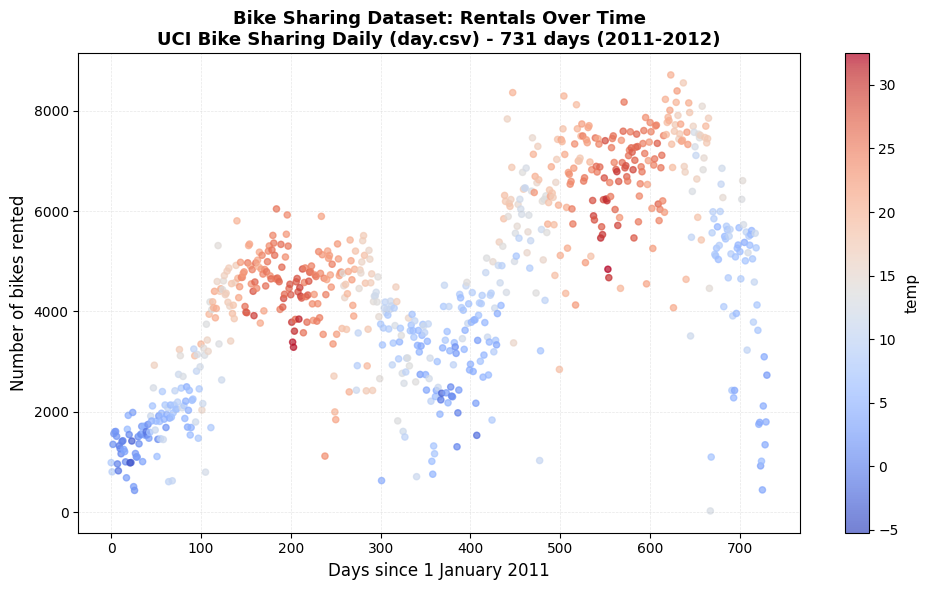


Data Patterns Observed:
1. TREND: Bike rentals generally increase over time (2011-2012)
2. SEASONALITY: Clear seasonal pattern with peaks in warm months
3. TEMPERATURE: Warmer days (red) tend to have more rentals
4. The correlation between temp and rentals is confounded by season


In [4]:
# Visualize: Number of bikes rented over time, colored by temperature
# This shows the raw data patterns before Shapley analysis

fig, ax = plt.subplots(figsize=(10, 6))

# Use full dataset for visualization (not centered)
trend_values = x_data['trend'].values
temp_values = x_data['temp'].values
y_values = y_data.values  # Original bike rental counts (not centered)

# Create scatter plot
scatter = ax.scatter(trend_values, y_values, c=temp_values, 
                     cmap='coolwarm', s=20, alpha=0.7)

ax.set_xlabel('Days since 1 January 2011', fontsize=12)
ax.set_ylabel('Number of bikes rented', fontsize=12)
ax.set_title('Bike Sharing Dataset: Rentals Over Time\n'
             'UCI Bike Sharing Daily (day.csv) - 731 days (2011-2012)', 
             fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('temp', fontsize=11)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nData Patterns Observed:")
print("=" * 60)
print("1. TREND: Bike rentals generally increase over time (2011-2012)")
print("2. SEASONALITY: Clear seasonal pattern with peaks in warm months")
print("3. TEMPERATURE: Warmer days (red) tend to have more rentals")
print("4. The correlation between temp and rentals is confounded by season")
print("=" * 60)

## 2. Train XGBoost Model

In [5]:
model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=1,
    verbosity=0
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Test RMSE (centered): {rmse:.2f}")

Test RMSE (centered): 775.24


## 3. Define Causal Structure

From Section 6 of the paper:
- **Layer 1 (Root cause)**: `{trend}`
- **Layer 2 (Confounded)**: `{cosyear, sinyear}` - season affects weather
- **Layer 3 (Mutual interactions)**: `{temp, atemp, windspeed, hum}`

Confounding:
- Layer 1: No confounding (singleton)
- Layer 2: **Confounding = True** (common cause breaks dependencies on intervention)
- Layer 3: No confounding (mutual interactions preserved)

> **Note**: However, from a strict causal perspective, **treating season as a cause of weather (or as same-layer causal variables) may be a misattribution**. An alternative corrected causal structure is available in `paper_figure3_alternative_ordering.ipynb` in the same directory for comparison.

In [6]:
# Causal ordering (matching shapr R package)
ordering = [
    [0],           # Layer 1: trend (root)
    [1, 2],        # Layer 2: cosyear, sinyear (confounded)
    [3, 4, 5, 6],  # Layer 3: temp, atemp, windspeed, hum
]

# Confounding per component
confounding = [False, True, False]

print("Causal Structure:")
for i, layer in enumerate(ordering):
    layer_names = [feature_names[j] for j in layer]
    print(f"  Layer {i+1}: {layer_names} (confounding={confounding[i]})")

Causal Structure:
  Layer 1: ['trend'] (confounding=False)
  Layer 2: ['cosyear', 'sinyear'] (confounding=True)
  Layer 3: ['temp', 'atemp', 'windspeed', 'hum'] (confounding=False)


## 4. Create Explainers

- **Marginal**: Standard SHAP (assumes feature independence)
- **Causal**: Uses CausalImputer with copula sampling

In [7]:
# Configuration (matching R code: seed=2020, n_samples=500)
RANDOM_STATE = 2020
SAMPLE_SIZE = 500

# Dictionary to store all explainers
explainers = {}

# =============================================================================
# 1. MARGINAL EXPLAINERS (No causal structure)
# =============================================================================

# 1a. Marginal (Joint) - Standard SHAP with joint marginal sampling
#     (empirical resampling, does not match R code's Gaussian approach)
explainers['Marginal (Joint)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# 1b. Marginal (Gaussian) - Gaussian assumption, no causal structure
#     [Used in paper reproduction as MSV - matches R code's Gaussian marginal approach]
#     sampling_method="gaussian" → sample X_S̄ from N(μ_S̄, Σ_S̄S̄) marginal distribution
explainers['Marginal (Gaussian)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    sampling_method="gaussian",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# 1c. Marginal (Copula) - Gaussian Copula, no causal structure
#     sampling_method="copula" → Gaussian copula preserving original marginal distributions
explainers['Marginal (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# =============================================================================
# 2. CAUSAL EXPLAINERS WITH MODEL (XGBoost)
# =============================================================================

# 2a. Causal + Model (Gaussian sampling)
#     ★ THIS IS THE PAPER'S CSV METHOD - Heskes et al. (2020) ★
explainers['Causal+Model (Gaussian)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="causal",
    ordering=ordering,
    confounding=confounding,
    sampling_method="gaussian",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# 2b. Causal + Model (Copula sampling) - Alternative with preserved marginals
explainers['Causal+Model (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="causal",
    ordering=ordering,
    confounding=confounding,
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# =============================================================================
# 3. CAUSAL EXPLAINER WITHOUT MODEL (Model-Free)
# =============================================================================

# 3. No-Model Causal - treats Y as final node in causal graph
explainers['Causal No-Model (Copula)'] = TabularExplainer(
    model=model.predict,       # placeholder; overridden internally
    data=X_train,
    imputer="no_model_causal", # unified string API
    y=y_train,                 # required for model-free Y estimation
    ordering=ordering,
    confounding=confounding,
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

print("All explainers created successfully!")
print(f"\nTotal explainers: {len(explainers)}")
print("\nMethods:")
for name in explainers:
    marker = "  ★ [Paper CSV]" if name == 'Causal+Model (Gaussian)' else ""
    marker = "  ★ [Paper MSV]" if name == 'Marginal (Gaussian)' else marker
    print(f"  - {name}{marker}")

All explainers created successfully!

Total explainers: 6

Methods:
  - Marginal (Joint)
  - Marginal (Gaussian)  ★ [Paper MSV]
  - Marginal (Copula)
  - Causal+Model (Gaussian)  ★ [Paper CSV]
  - Causal+Model (Copula)
  - Causal No-Model (Copula)


## 5. Compute Shapley Values for All Test Samples

>  **Note**: This step computes Shapley values for all 6 methods across all test samples. Expected runtime: **20-40 minutes** depending on your hardware.

In [ ]:
budget = 2048
n_features = len(feature_names)

# Store all k-SII results (InteractionValues objects) and extracted 1st-order values
all_ksii = {}  # Full InteractionValues for each sample
all_sv = {}    # 1st-order values only (for backward compatibility with existing plots)

for exp_name, explainer in explainers.items():
    print(f"\nComputing k-SII (max_order=2) for {exp_name} across {len(X_test)} samples...")
    ksii_list = []  # Store full InteractionValues for each sample
    sv = np.zeros((len(X_test), n_features))
    
    for i in range(len(X_test)):
        result = explainer.explain(X_test[i:i+1], budget=budget)
        ksii_list.append(result)  # Store full result with interactions
        sv[i] = result.get_n_order_values(order=1)  # Extract 1st-order for backward compat
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(X_test)}")
    
    all_ksii[exp_name] = ksii_list
    all_sv[exp_name] = sv
    print(f"  Done!")

print("\n" + "="*50)
print("All k-SII values (1st & 2nd order) computed successfully!")
print("="*50)
print(f"\nStored data:")
print(f"  all_ksii: Full InteractionValues for each sample (includes 2nd-order interactions)")
print(f"  all_sv: 1st-order values only (n_samples x n_features arrays)")


Computing k-SII (max_order=2) for Marginal (Joint) across 144 samples...


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 50/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 100/144


...

E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 50/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 100/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

## 6. Scatter Plots: 2×2 Grid Comparison

> **Note**: This section is a **pure reproduction** of Figure 3 from Heskes et al. (2020). We use only:
> - **MSV**: Marginal (Joint) - standard marginal SHAP
> - **CSV**: Causal+Model (Gaussian) - the method proposed in the paper
>
> For comprehensive comparison across all 6 imputation methods, see **Part II** (Section 11 onwards).

The original Figure 3 shows a 2×2 scatter plot grid:
- **Top left**: MSV temp (x) vs MSV cosyear (y)
- **Top right**: CSV cosyear (x) vs MSV cosyear (y)
- **Bottom left**: MSV temp (x) vs CSV temp (y)
- **Bottom right**: CSV cosyear (x) vs CSV temp (y)

All colored by temperature (blue=cold, red=hot).

![alt text](scatter_plots_top_page-0001.jpg)![alt text](scatter_plots_bottom_page-0001.jpg)

In [ ]:
# For paper reproduction: use only the two methods from Heskes et al. (2020)
# - MSV: Marginal (Gaussian) = Gaussian marginal sampling (matching R code's causal approach with confounding=TRUE)
# - CSV: Causal+Model (Gaussian) = the Causal SHAP method from the paper
sv_marginal = all_sv['Marginal (Gaussian)']
sv_causal = all_sv['Causal+Model (Gaussian)']  # This is the paper's CSV method same as the original supplementary code

C:\Users\bodun\AppData\Local\Temp\ipykernel_8100\3253742336.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.92])


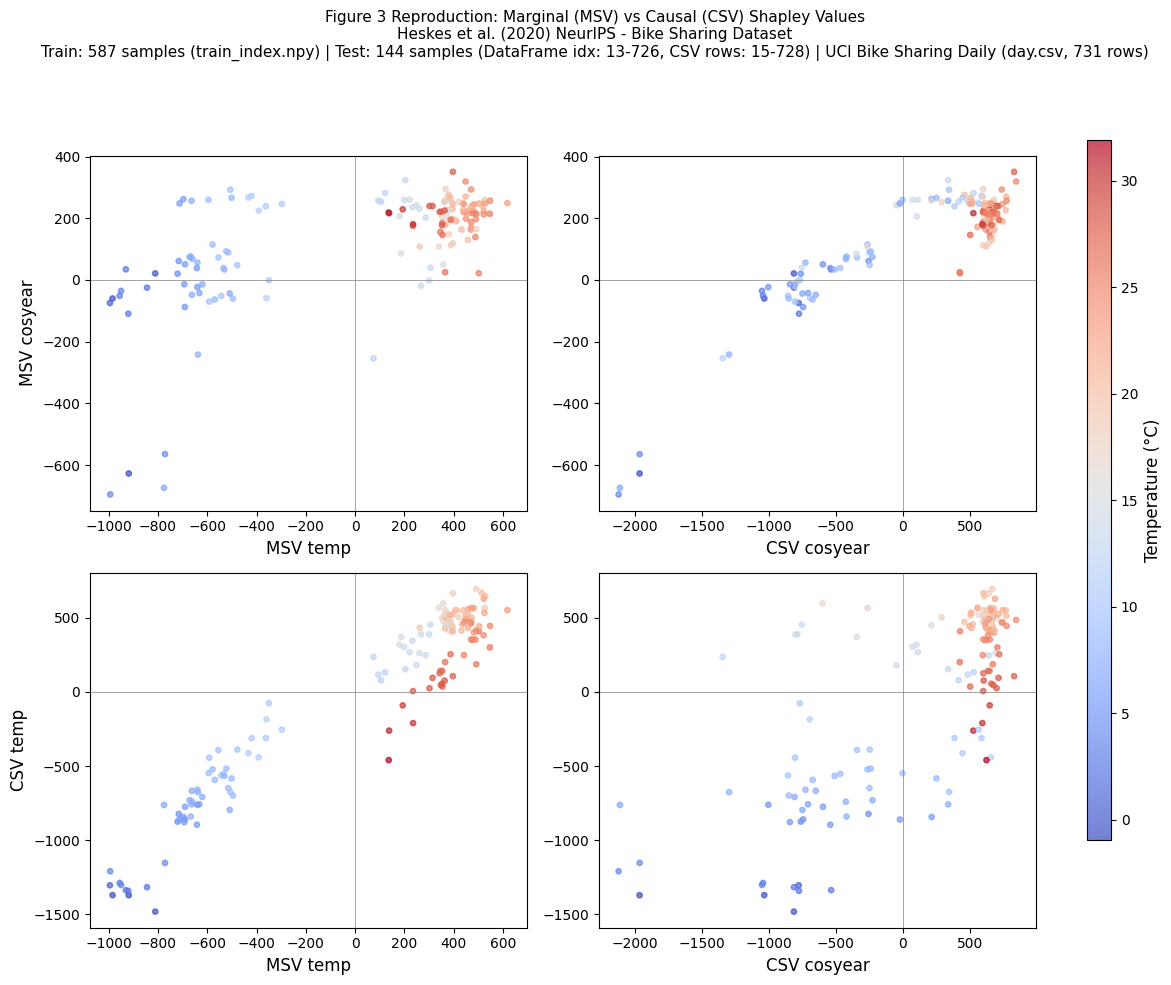

In [ ]:
# Get feature indices
temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')

# Get Shapley values for temp and cosyear
sv_marg_temp = sv_marginal[:, temp_idx]
sv_marg_cosyear = sv_marginal[:, cosyear_idx]
sv_caus_temp = sv_causal[:, temp_idx]
sv_caus_cosyear = sv_causal[:, cosyear_idx]

# Temperature values for coloring
temp_values = X_test[:, temp_idx]

# Create 2x2 figure matching paper layout (wider to accommodate colorbar)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cmap = 'coolwarm'
point_size = 15

# Top left: MSV temp (x) vs MSV cosyear (y)
ax = axes[0, 0]
scatter = ax.scatter(sv_marg_temp, sv_marg_cosyear, c=temp_values, 
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('MSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Top right: CSV cosyear (x) vs MSV cosyear (y)
ax = axes[0, 1]
ax.scatter(sv_caus_cosyear, sv_marg_cosyear, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom left: MSV temp (x) vs CSV temp (y)
ax = axes[1, 0]
ax.scatter(sv_marg_temp, sv_caus_temp, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('CSV temp', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom right: CSV cosyear (x) vs CSV temp (y)
ax = axes[1, 1]
scatter = ax.scatter(sv_caus_cosyear, sv_caus_temp, c=temp_values,
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Add colorbar with better positioning
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=12)

# Get test CSV rows for display
test_csv_rows = test_idx + 2
plt.suptitle('Figure 3 Reproduction: Marginal (MSV) vs Causal (CSV) Shapley Values\n'
             'Heskes et al. (2020) NeurIPS - Bike Sharing Dataset\n'
             f'Train: {len(train_idx)} samples (train_index.npy) | '
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]}) | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=11)
plt.tight_layout(rect=[0, 0, 0.88, 0.92])
plt.show()

### 6.1. Interpretation

The key insight from Figure 3:

**Marginal Shapley Values (MSV)**:
- `temp` shows strong positive/negative contributions
- `cosyear` shows weaker contributions
- Points form a linear pattern due to correlation between temp and season

**Causal Shapley Values (CSV)**:
- `cosyear` (season) absorbs much of the attribution that was on `temp`
- This is because season is a **root cause** of temperature
- When we intervene on season, temperature follows naturally
- CSV correctly attributes importance to the causal root (season)

## 6.2. Beeswarm Comparison (All Methods)

![alt text](sina_plot_causal_page-0001.jpg)

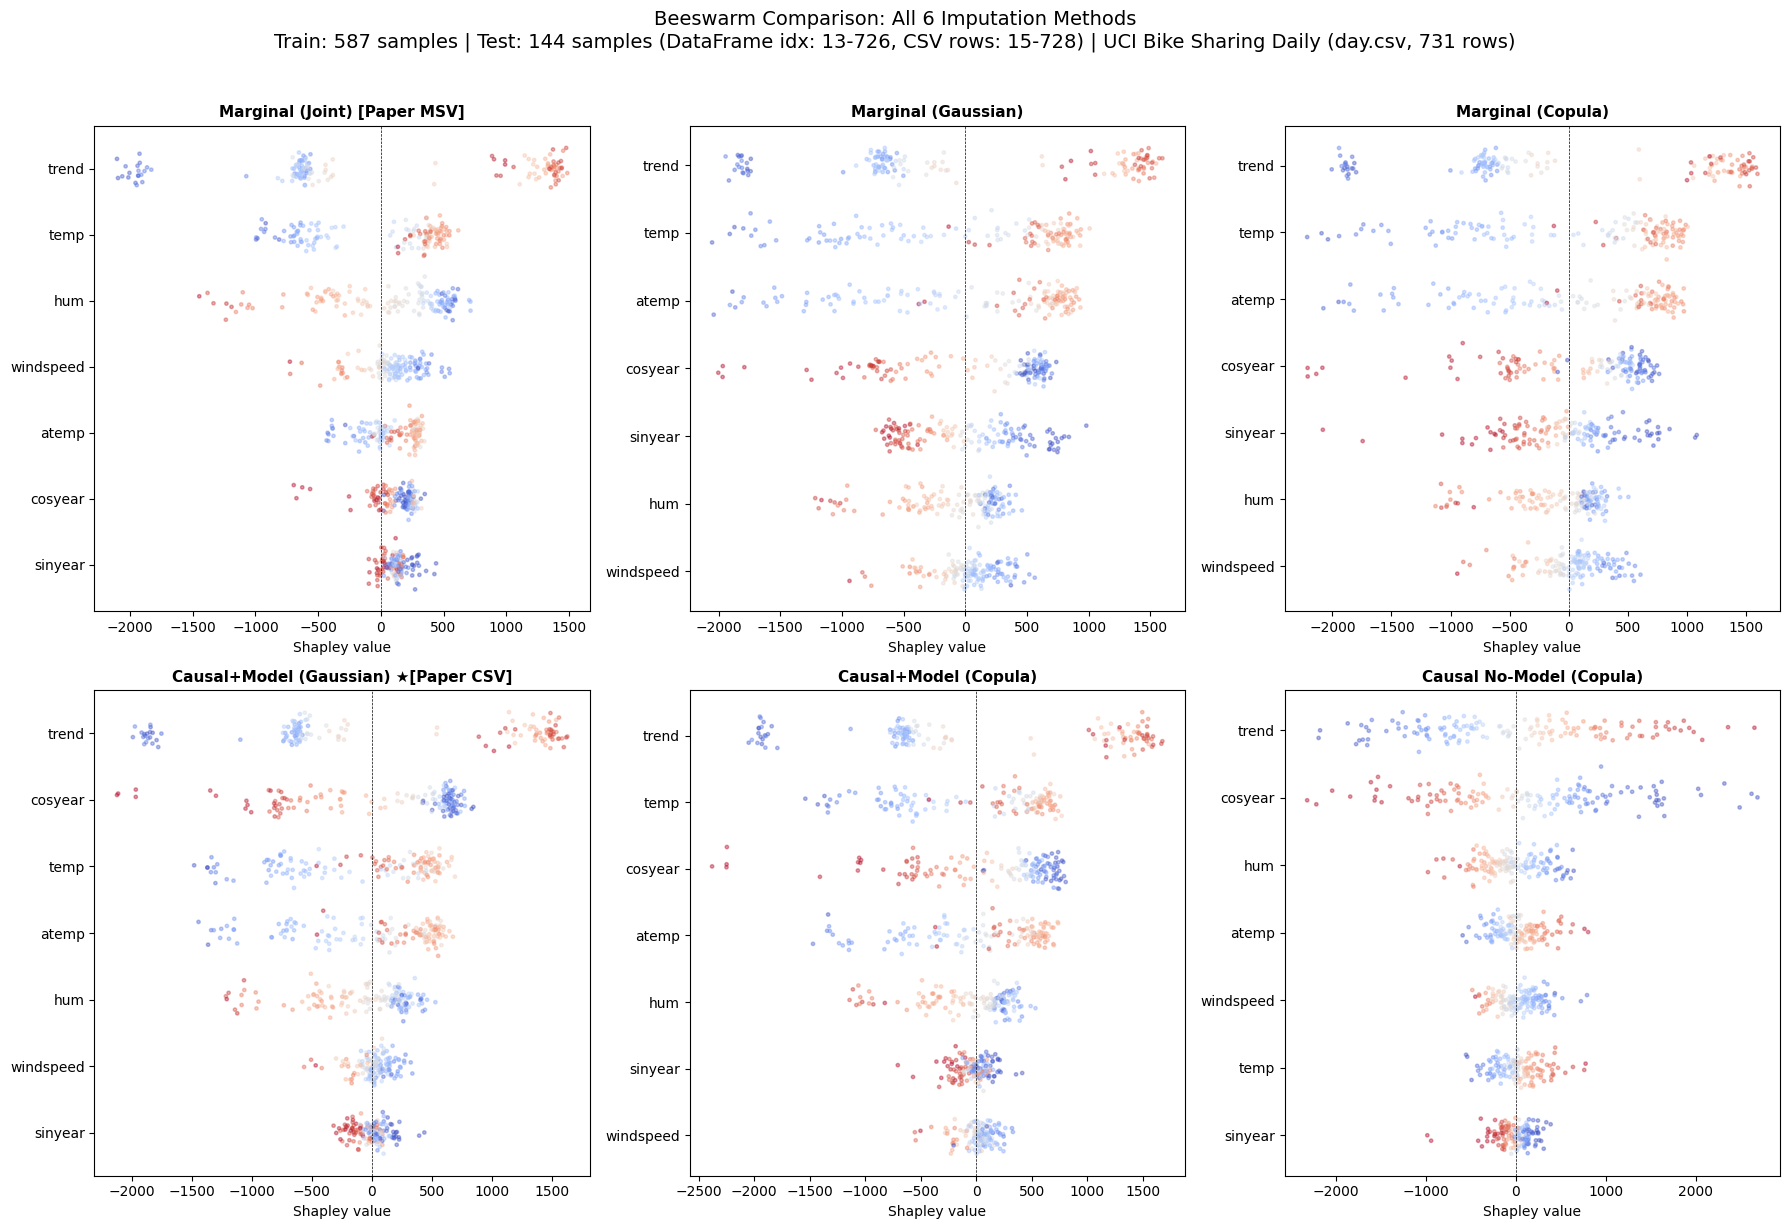

In [ ]:
# Create 2x3 beeswarm comparison for ALL methods
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    # Feature importance order (by mean absolute value)
    importance = np.abs(sv).mean(axis=0)
    order = np.argsort(importance)[::-1]
    
    for i, f_idx in enumerate(order):
        fv = X_test[:, f_idx]
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-10)
        
        y_jitter = np.random.normal(0, 0.12, len(sv)) + (len(feature_names) - 1 - i)
        ax.scatter(sv[:, f_idx], y_jitter, c=fv_norm, cmap='coolwarm', 
                  alpha=0.4, s=6)
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[order[len(feature_names) - 1 - i]] 
                        for i in range(len(feature_names))])
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Shapley value')
    
    # Mark paper methods
    title = exp_name
    if exp_name == 'Marginal (Gaussian)':
        title += ' ★[Paper MSV]'
    elif exp_name == 'Causal+Model (Gaussian)':
        title += ' ★[Paper CSV]'
    ax.set_title(title, fontsize=11, fontweight='bold')

# Get test CSV rows for display
test_csv_rows = test_idx + 2
plt.suptitle('Beeswarm Comparison: All 6 Imputation Methods\n'
             f'Train: {len(train_idx)} samples | '
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]}) | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Summary Statistics

> **Note**: The summary statistics comparison is inspired by the analysis approach in Heskes et al. (2020), where the authors compared feature attributions between MSV and CSV. Here we extend this comparison to all 6 imputation methods to provide a comprehensive understanding of how different modeling assumptions affect Shapley value attributions.

In [ ]:
# Create summary DataFrame for all methods
test_csv_rows = test_idx + 2
print("="*90)
print("SUMMARY STATISTICS: Mean Absolute Shapley Values for All Methods")
print(f"Data: Test set with {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})")
print("="*90)

summary_df = pd.DataFrame(index=feature_names)
for exp_name, sv in all_sv.items():
    summary_df[exp_name] = np.abs(sv).mean(axis=0)

# Shorter column names for display
short_names = {
    'Marginal (Joint)': 'Marg(Joint)',
    'Marginal (Gaussian)': 'Marg(Gauss)',
    'Marginal (Copula)': 'Marg(Copula)',
    'Causal+Model (Gaussian)': 'Caus(Gauss)★',
    'Causal+Model (Copula)': 'Caus(Copula)',
    'Causal No-Model (Copula)': 'NoModel'
}
summary_df.columns = [short_names.get(c, c) for c in summary_df.columns]

print("\n" + summary_df.round(2).to_string())

# Show key comparison: temp vs cosyear ratio
print("\n" + "-"*90)
print("Key Metric: cosyear/temp ratio (higher = more attribution to root cause)")
print("-"*90)
temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')

for exp_name, sv in all_sv.items():
    temp_mean = np.abs(sv[:, temp_idx]).mean()
    cosyear_mean = np.abs(sv[:, cosyear_idx]).mean()
    ratio = cosyear_mean / temp_mean if temp_mean > 0 else 0
    marker = " ★[Paper CSV]" if exp_name == 'Causal+Model (Gaussian)' else ""
    marker = " ★[Paper MSV]" if exp_name == 'Marginal (Gaussian)' else marker
    print(f"  {exp_name:<30} ratio = {ratio:.3f}{marker}")

SUMMARY STATISTICS: Mean Absolute Shapley Values for All Methods
Data: Test set with 144 samples (DataFrame idx: 13-726, CSV rows: 15-728)

           Marg(Joint)  Marg(Gauss)  Marg(Copula)  Caus(Gauss)★  Caus(Copula)  NoModel
trend          1055.21      1042.20       1065.47       1059.45       1077.53   893.88
cosyear         184.36       592.48        525.99        638.63        567.59   840.00
sinyear         123.71       397.27        359.17        105.86        111.94   142.69
temp            471.22       749.86        779.72        519.75        584.67   188.89
atemp           187.06       741.92        711.51        478.61        496.61   199.14
windspeed       191.65       196.23        220.02        106.98        111.09   188.93
hum             449.24       302.44        279.60        326.15        313.47   279.78

------------------------------------------------------------------------------------------
Key Metric: cosyear/temp ratio (higher = more attribution to root cause)

## 10. Two Similar Days Analysis

> **Note**: This analysis replicates the "two similar days" comparison from Heskes et al. (2020), where the authors demonstrated how MSV and CSV differ in explaining predictions for days with similar temperatures but different seasons. We extend this visualization to include all 6 imputation methods, allowing for a comprehensive comparison across different modeling assumptions.

Following the paper's analysis: compare two days with similar temperatures but different seasons.![alt text](bar_plots_page-0001.jpg)

October day (DataFrame idx 75, CSV row 77): temp=11.5°C, cosyear=0.28
December day (DataFrame idx 44, CSV row 46): temp=11.5°C, cosyear=0.73


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

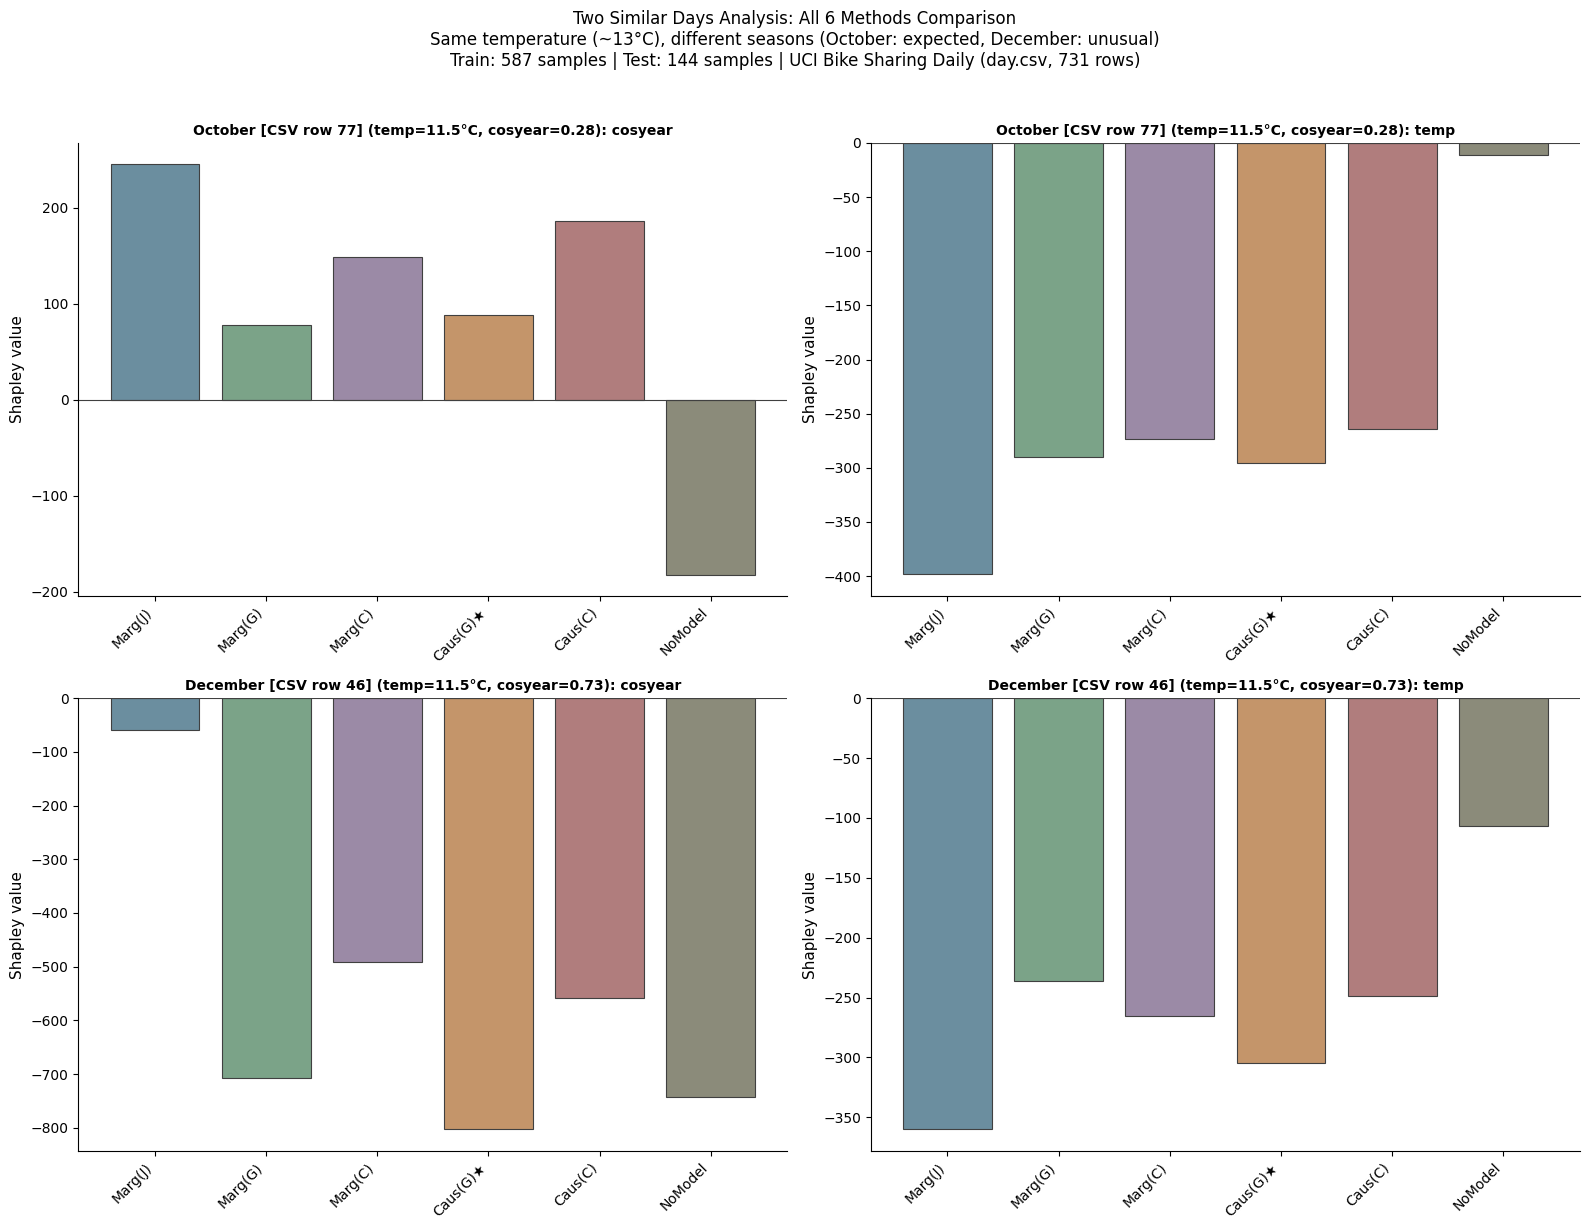


TWO SIMILAR DAYS: SHAPLEY VALUE COMPARISON

October day (DataFrame idx 75, CSV row 77): temp=11.5°C, cosyear=0.28
December day (DataFrame idx 44, CSV row 46): temp=11.5°C, cosyear=0.73

--------------------------------------------------------------------------------
Method                          Oct cosyear  Dec cosyear     Oct temp     Dec temp
--------------------------------------------------------------------------------
Marginal (Joint)                     245.89       -58.53      -398.26      -360.13
Marginal (Gaussian)                   77.24      -706.46      -290.23      -236.34
Marginal (Copula)                    148.38      -492.06      -273.58      -265.13
Causal+Model (Gaussian)               87.85      -802.98      -295.68      -304.76 ★
Causal+Model (Copula)                185.97      -557.93      -264.37      -248.97
Causal No-Model (Copula)            -182.91      -741.68       -10.70      -106.83

INTERPRETATION:

Both days have similar temperatures (~13°C), but:


In [ ]:
# Use the EXACT same two days as the R original code (bike_rental_illustration.R):
#   october <- which(... bike$dteday == "2012-10-09")
#   december <- which(... bike$dteday == "2012-12-03")
# In day.csv: instant 648 = 2012-10-09, instant 703 = 2012-12-03
# DataFrame index (0-based) = instant - 1

# Get full data
x_full, y_full = load_bike_sharing_daily(preprocessed=True)

# Exact indices matching the R code's date-based selection
october_idx = 647   # 2012-10-09 (instant=648): temp≈13.0°C, cosyear≈0.14
december_idx = 702  # 2012-12-03 (instant=703): temp≈13.3°C, cosyear≈0.89

# CSV row = DataFrame index + 2 (header + 0-based index)
october_csv_row = october_idx + 2
december_csv_row = december_idx + 2

print(f"October day 2012-10-09 (DataFrame idx {october_idx}, CSV row {october_csv_row}): "
      f"temp={x_full.loc[october_idx, 'temp']:.1f}°C, "
      f"cosyear={x_full.loc[october_idx, 'cosyear']:.2f}")
print(f"December day 2012-12-03 (DataFrame idx {december_idx}, CSV row {december_csv_row}): "
      f"temp={x_full.loc[december_idx, 'temp']:.1f}°C, "
      f"cosyear={x_full.loc[december_idx, 'cosyear']:.2f}")

# Compute Shapley values for these two days using ALL methods
days_x = x_full.loc[[october_idx, december_idx], feature_names].values

# Store results for all methods
sv_days_all = {}
for exp_name, explainer in explainers.items():
    sv_days = []
    for x in days_x:
        result = explainer.explain(x.reshape(1, -1), budget=budget)
        sv_days.append(result.get_n_order_values(order=1))
    sv_days_all[exp_name] = np.array(sv_days)

# Plot comparison for all 6 methods
# Academic low-saturation color palette
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#7BA388',  # Muted sage green (Marginal Gaussian)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#C4956A',  # Muted terracotta (Causal Gaussian) ★
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-Model)
]
short_names = ['Marg(J)', 'Marg(G)', 'Marg(C)', 'Caus(G)★', 'Caus(C)', 'NoModel']

# Get raw data for display
oct_temp = x_full.loc[october_idx, 'temp']
oct_cosyear = x_full.loc[october_idx, 'cosyear']
dec_temp = x_full.loc[december_idx, 'temp']
dec_cosyear = x_full.loc[december_idx, 'cosyear']

for ax_idx, (fname, f_idx) in enumerate([('cosyear', cosyear_idx), ('temp', temp_idx)]):
    # October day
    ax = axes[0, ax_idx]
    x_pos = np.arange(len(explainers))
    values = [sv_days_all[name][0, f_idx] for name in explainers.keys()]
    bars = ax.bar(x_pos, values, color=colors, edgecolor='#404040', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.axhline(y=0, color='#404040', linewidth=0.8)
    ax.set_ylabel('Shapley value', fontsize=11)
    ax.set_title(f'October 2012-10-09 [CSV row {october_csv_row}] (temp={oct_temp:.1f}°C, cosyear={oct_cosyear:.2f}): {fname}', 
                 fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # December day
    ax = axes[1, ax_idx]
    values = [sv_days_all[name][1, f_idx] for name in explainers.keys()]
    bars = ax.bar(x_pos, values, color=colors, edgecolor='#404040', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.axhline(y=0, color='#404040', linewidth=0.8)
    ax.set_ylabel('Shapley value', fontsize=11)
    ax.set_title(f'December 2012-12-03 [CSV row {december_csv_row}] (temp={dec_temp:.1f}°C, cosyear={dec_cosyear:.2f}): {fname}', 
                 fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Two Similar Days Analysis (Figure 4 Reproduction): All 6 Methods\n'
             '2012-10-09 (October, expected temp) vs 2012-12-03 (December, unusual warmth)\n'
             f'Train: {len(train_idx)} samples | Test: {len(test_idx)} samples | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("TWO SIMILAR DAYS: SHAPLEY VALUE COMPARISON")
print("="*80)
print(f"\nOctober 2012-10-09 (DataFrame idx {october_idx}, CSV row {october_csv_row}): "
      f"temp={x_full.loc[october_idx, 'temp']:.1f}°C, cosyear={x_full.loc[october_idx, 'cosyear']:.2f}")
print(f"December 2012-12-03 (DataFrame idx {december_idx}, CSV row {december_csv_row}): "
      f"temp={x_full.loc[december_idx, 'temp']:.1f}°C, cosyear={x_full.loc[december_idx, 'cosyear']:.2f}")

print("\n" + "-"*80)
print(f"{'Method':<30} {'Oct cosyear':>12} {'Dec cosyear':>12} {'Oct temp':>12} {'Dec temp':>12}")
print("-"*80)
for exp_name in explainers.keys():
    sv = sv_days_all[exp_name]
    marker = " ★" if exp_name == 'Causal+Model (Gaussian)' else ""
    print(f"{exp_name:<30} {sv[0, cosyear_idx]:>12.2f} {sv[1, cosyear_idx]:>12.2f} "
          f"{sv[0, temp_idx]:>12.2f} {sv[1, temp_idx]:>12.2f}{marker}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("""
Both days have similar temperatures (~13°C), but:
- October 2012-10-09: This temp is EXPECTED for the season
- December 2012-12-03: This temp is UNUSUAL (warm for winter)

Key observations across methods:
1. MARGINAL methods: Similar temp attribution for both days
2. CAUSAL methods: Higher cosyear attribution for December (unusual warmth)
3. The causal methods correctly identify that December's warm weather
   should be attributed more to the unusual season (cosyear)
""")

---

# Part II: Comprehensive Imputer Comparison (Additional Analysis)

> **Note**: This section contains **additional exploratory analysis** beyond the paper reproduction. These visualizations provide deeper insights into the differences between all 6 imputation methods and are useful for understanding the behavior of various Shapley value computation approaches.

Now we compare all 6 imputation methods systematically to understand how different assumptions affect Shapley value attributions.

## 11. Feature Importance Comparison Across All Imputers

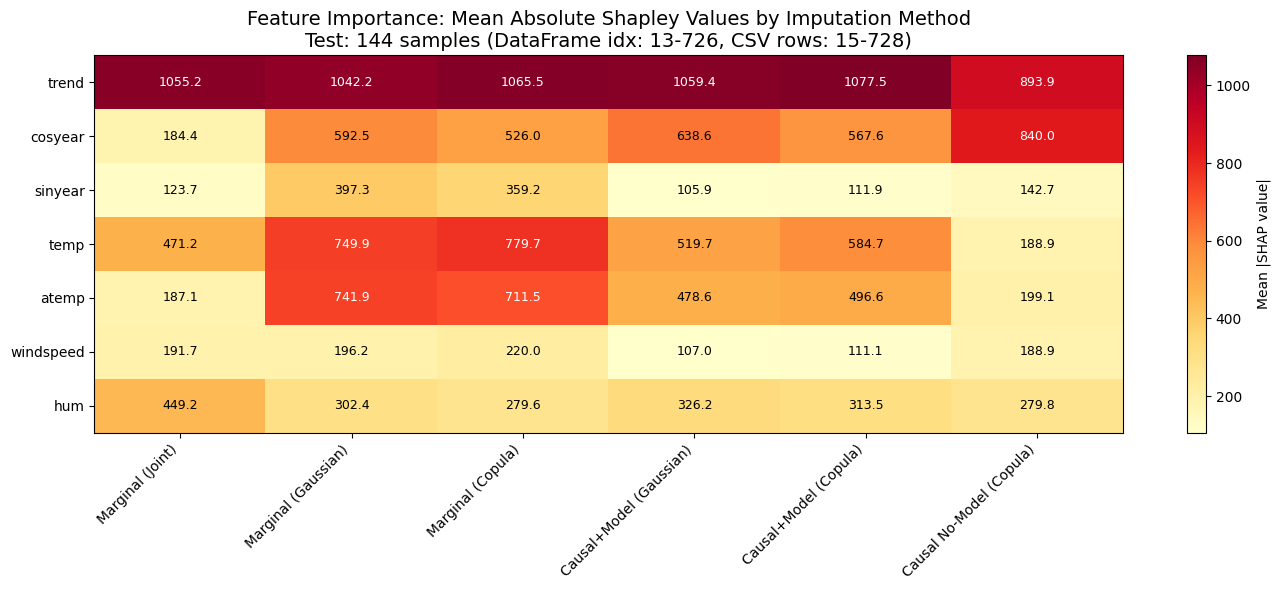

           Marginal (Joint)  Marginal (Gaussian)  Marginal (Copula)  Causal+Model (Gaussian)  Causal+Model (Copula)  Causal No-Model (Copula)
trend               1055.21              1042.20            1065.47                  1059.45                1077.53                    893.88
cosyear              184.36               592.48             525.99                   638.63                 567.59                    840.00
sinyear              123.71               397.27             359.17                   105.86                 111.94                    142.69
temp                 471.22               749.86             779.72                   519.75                 584.67                    188.89
atemp                187.06               741.92             711.51                   478.61                 496.61                    199.14
windspeed            191.65               196.23             220.02                   106.98                 111.09                    188.93
hum   

In [ ]:
# Compute mean absolute Shapley values for all methods
importance_df = pd.DataFrame(index=feature_names)

for exp_name, sv in all_sv.items():
    importance_df[exp_name] = np.abs(sv).mean(axis=0)

# Display as heatmap
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(importance_df.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(importance_df.columns)))
ax.set_xticklabels(importance_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(importance_df.index)))
ax.set_yticklabels(importance_df.index)

# Add text annotations
for i in range(len(importance_df.index)):
    for j in range(len(importance_df.columns)):
        val = importance_df.iloc[i, j]
        color = 'white' if val > importance_df.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='Mean |SHAP value|')
test_csv_rows = test_idx + 2
plt.title(f'Feature Importance: Mean Absolute Shapley Values by Imputation Method\n'
         f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
         fontsize=14)
plt.tight_layout()
plt.show()

print(importance_df.round(2).to_string())

print("\nFeature Importance Table:")
print(f"Data: Test set with {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})")

## 13. Focus on temp vs cosyear Attribution

The key comparison: how does each method attribute importance between temperature (direct effect) and season (root cause)?

C:\Users\bodun\AppData\Local\Temp\ipykernel_8100\1489536100.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


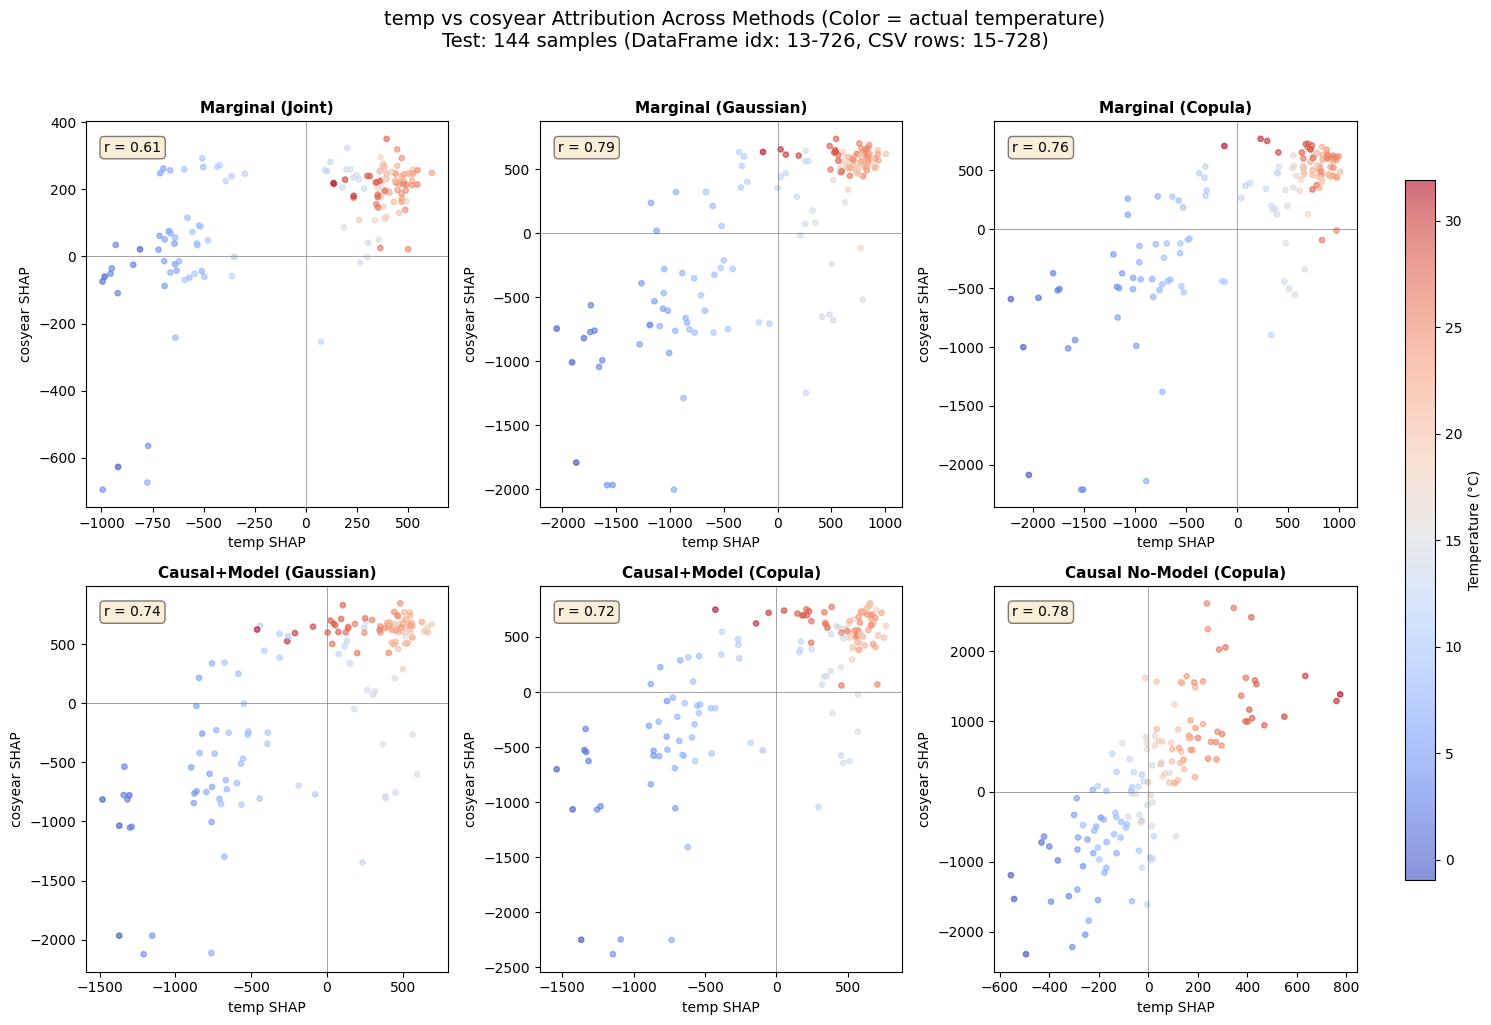

In [ ]:
# Scatter: temp SHAP vs cosyear SHAP for each method
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')
temp_values = X_test[:, temp_idx]

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    scatter = ax.scatter(
        sv[:, temp_idx], 
        sv[:, cosyear_idx], 
        c=temp_values,
        cmap='coolwarm', 
        s=15, 
        alpha=0.6
    )
    
    ax.set_xlabel('temp SHAP')
    ax.set_ylabel('cosyear SHAP')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(exp_name, fontsize=11, fontweight='bold')
    
    # Add correlation coefficient
    corr = np.corrcoef(sv[:, temp_idx], sv[:, cosyear_idx])[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)')

test_csv_rows = test_idx + 2
plt.suptitle(f'temp vs cosyear Attribution Across Methods (Color = actual temperature)\n'
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

## 14. Grouped Bar Chart: Marginal vs Causal Methods

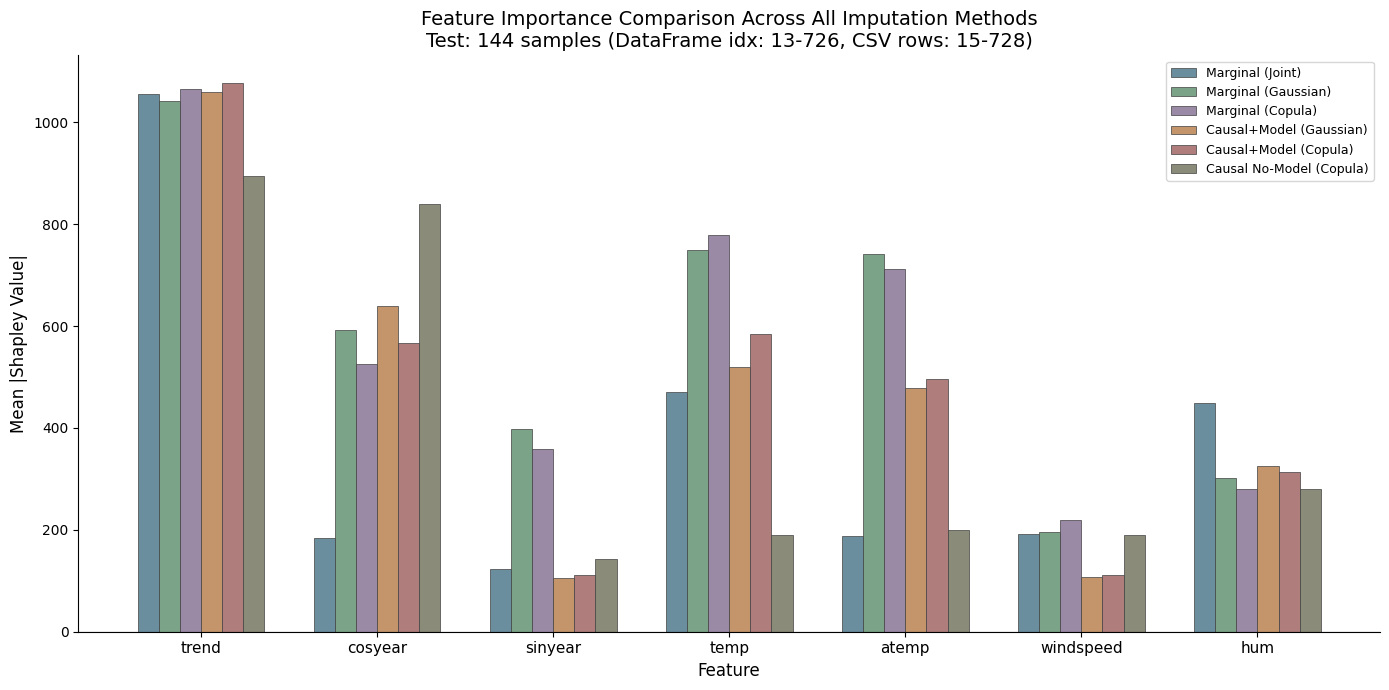

In [ ]:
# Grouped bar chart for mean absolute importance
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(feature_names))
width = 0.12
multiplier = 0

# Academic low-saturation colors (same as Chapter 10)
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#7BA388',  # Muted sage green (Marginal Gaussian)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#C4956A',  # Muted terracotta (Causal Gaussian) ★
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-Model)
]

for i, (exp_name, sv) in enumerate(all_sv.items()):
    importance = np.abs(sv).mean(axis=0)
    offset = width * multiplier
    bars = ax.bar(x + offset, importance, width, label=exp_name, color=colors[i], edgecolor='#404040', linewidth=0.5)
    multiplier += 1

ax.set_ylabel('Mean |Shapley Value|', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
test_csv_rows = test_idx + 2
ax.set_title(f'Feature Importance Comparison Across All Imputation Methods\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(feature_names, fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 15. Correlation Matrix Between Methods

How similar are the Shapley values from different methods?

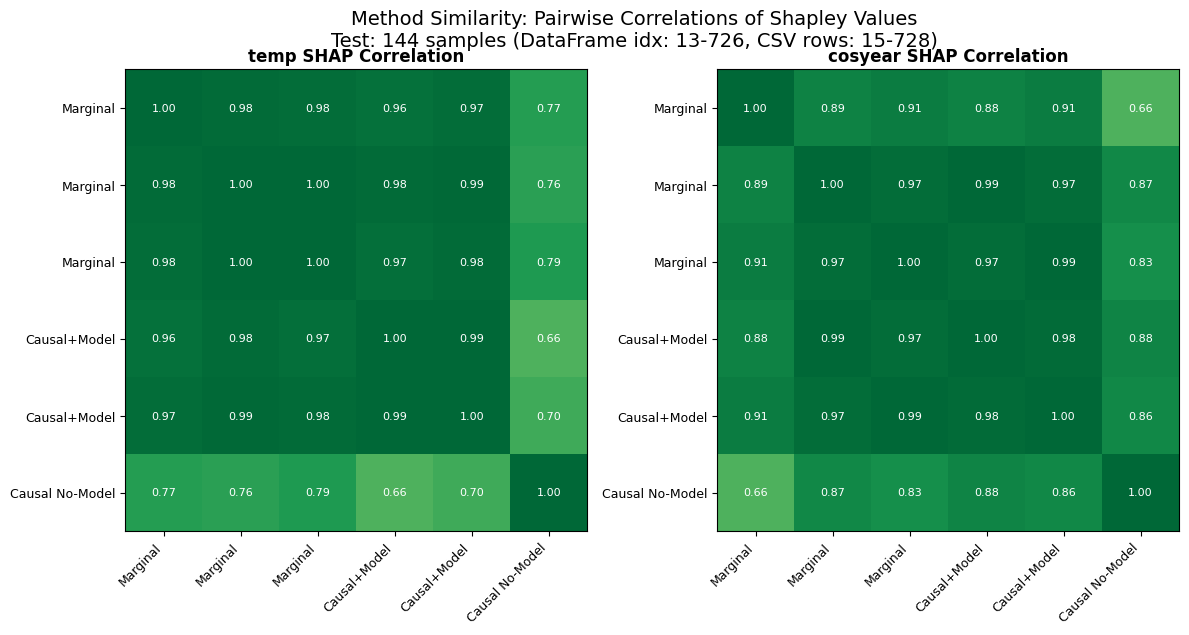

In [ ]:
# Compute pairwise correlations for temp and cosyear SHAP values
methods = list(all_sv.keys())
n_methods = len(methods)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('cosyear', cosyear_idx)]):
    corr_matrix = np.zeros((n_methods, n_methods))
    
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            corr_matrix[i, j] = np.corrcoef(
                all_sv[m1][:, feat_idx], 
                all_sv[m2][:, feat_idx]
            )[0, 1]
    
    ax = axes[ax_idx]
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels([m.split('(')[0].strip() for m in methods], rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([m.split('(')[0].strip() for m in methods], fontsize=9)
    
    # Add correlation values
    for i in range(n_methods):
        for j in range(n_methods):
            color = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
            ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', 
                   color=color, fontsize=8)
    
    ax.set_title(f'{feat_name} SHAP Correlation', fontsize=12, fontweight='bold')

# Adjust layout to prevent colorbar overlap
test_csv_rows = test_idx + 2
plt.suptitle(f'Method Similarity: Pairwise Correlations of Shapley Values\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, y=0.98)
plt.show()

## 16. Distribution Comparison: Marginal vs Causal Groups

C:\Users\bodun\AppData\Local\Temp\ipykernel_8100\1365233797.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=short_names, patch_artist=True)
C:\Users\bodun\AppData\Local\Temp\ipykernel_8100\1365233797.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=short_names, patch_artist=True)


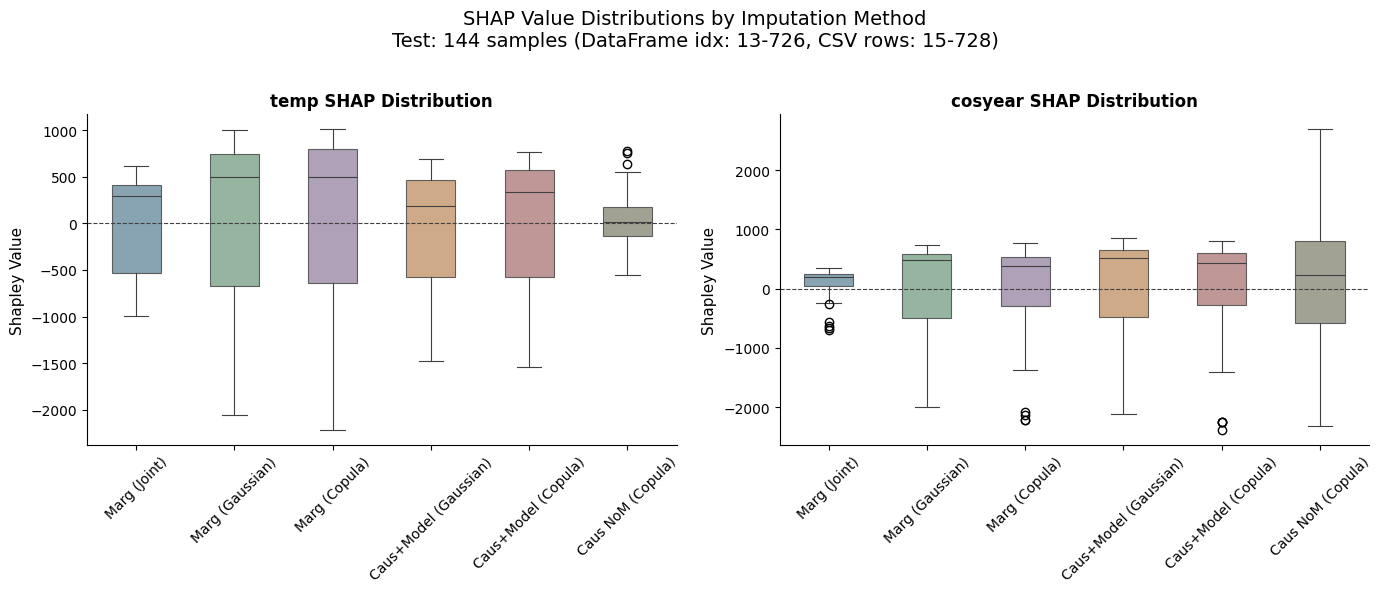

In [ ]:
# Box plots for temp and cosyear SHAP distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Academic low-saturation colors (same as Chapter 10 and 14)
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#7BA388',  # Muted sage green (Marginal Gaussian)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#C4956A',  # Muted terracotta (Causal Gaussian) ★
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-Model)
]

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('cosyear', cosyear_idx)]):
    ax = axes[ax_idx]
    
    data_to_plot = [all_sv[m][:, feat_idx] for m in methods]
    short_names = [m.replace('Marginal', 'Marg').replace('Causal', 'Caus').replace('No-Model', 'NoM') 
                   for m in methods]
    
    bp = ax.boxplot(data_to_plot, labels=short_names, patch_artist=True)
    
    # Apply individual colors to each box
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i])
        patch.set_edgecolor('#404040')
        patch.set_linewidth(0.8)
        patch.set_alpha(0.8)
    
    # Style whiskers, caps, and medians
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('#404040')
            item.set_linewidth(0.8)
    
    ax.axhline(y=0, color='#404040', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Shapley Value', fontsize=11)
    ax.set_title(f'{feat_name} SHAP Distribution', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

test_csv_rows = test_idx + 2
plt.suptitle(f'SHAP Value Distributions by Imputation Method\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 17. Summary Table and Key Insights

COMPREHENSIVE IMPUTER COMPARISON SUMMARY
Data: Test set with 144 samples (DataFrame idx: 13-726, CSV rows: 15-728)

                  Method  |temp| mean  |cosyear| mean  cosyear/temp ratio     Category
        Marginal (Joint)   471.222369      184.358202            0.391234     Marginal
     Marginal (Gaussian)   749.855068      592.480709            0.790127     Marginal
       Marginal (Copula)   779.715354      525.989810            0.674592     Marginal
 Causal+Model (Gaussian)   519.748508      638.628055            1.228725 Causal+Model
   Causal+Model (Copula)   584.665919      567.588171            0.970791 Causal+Model
Causal No-Model (Copula)   188.893693      839.997634            4.446933     No-Model

KEY INSIGHTS

1. MARGINAL METHODS (Joint, Gaussian, Copula):
   - All assign high importance to 'temp' directly
   - Lower attribution to 'cosyear' (season)
   - cosyear/temp ratio < 1: temperature dominates

2. CAUSAL + MODEL METHODS (Gaussian, Copula):
   - Shift attribut

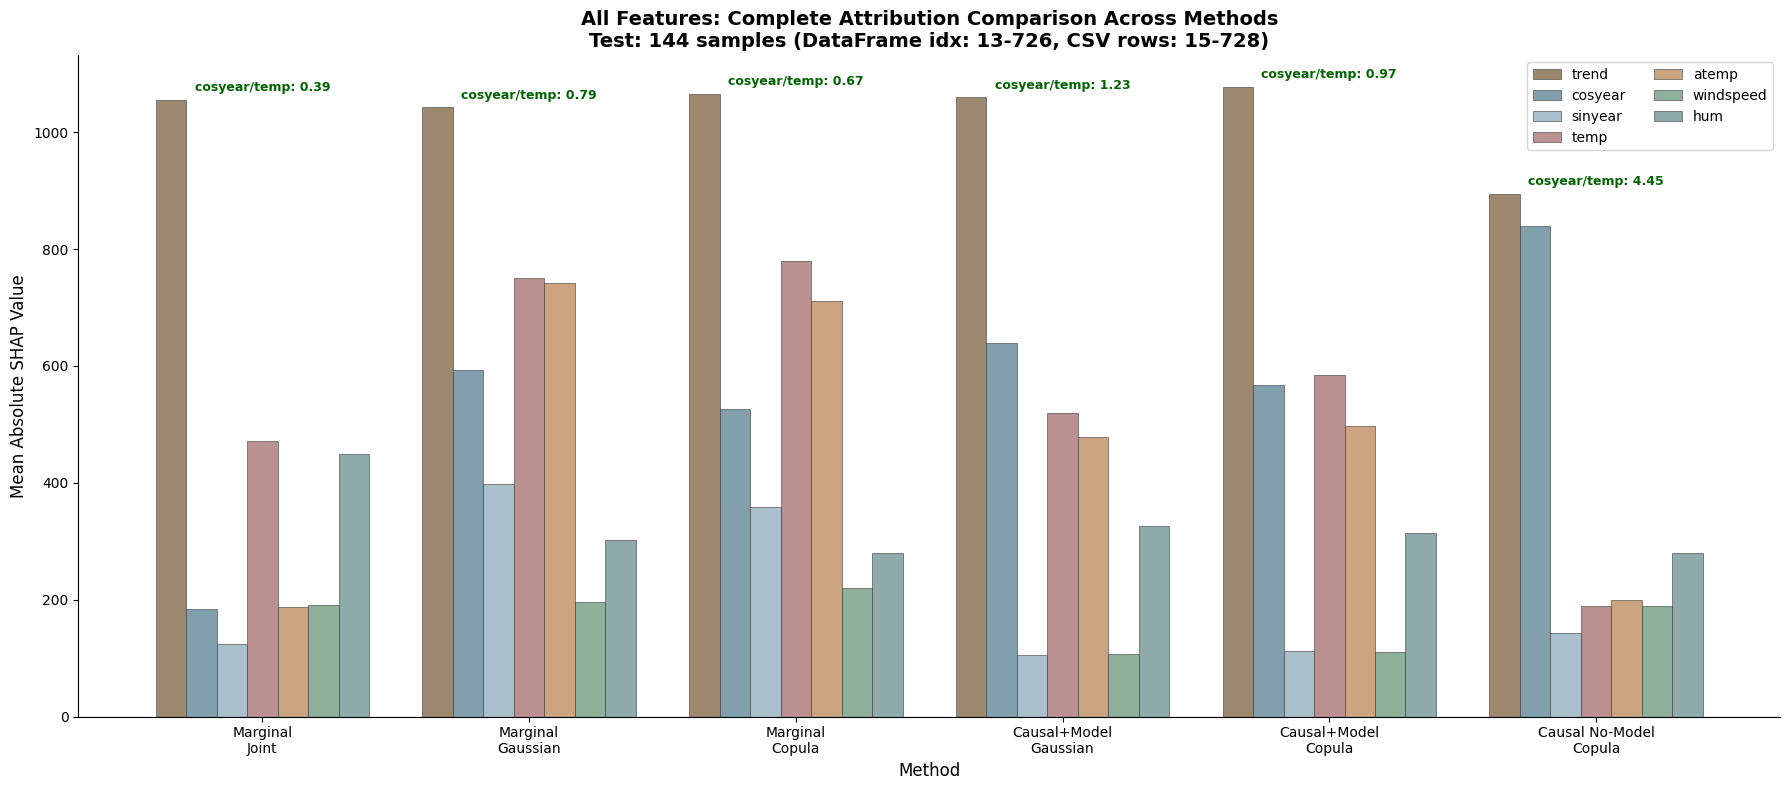

In [ ]:
# Summary statistics
test_csv_rows = test_idx + 2
print("="*80)
print("COMPREHENSIVE IMPUTER COMPARISON SUMMARY")
print(f"Data: Test set with {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})")
print("="*80)

# Create summary DataFrame
summary_data = []
for exp_name, sv in all_sv.items():
    temp_mean = np.abs(sv[:, temp_idx]).mean()
    cosyear_mean = np.abs(sv[:, cosyear_idx]).mean()
    ratio = cosyear_mean / temp_mean if temp_mean > 0 else 0
    
    summary_data.append({
        'Method': exp_name,
        '|temp| mean': temp_mean,
        '|cosyear| mean': cosyear_mean,
        'cosyear/temp ratio': ratio,
        'Category': 'Marginal' if 'Marginal' in exp_name else ('No-Model' if 'No-Model' in exp_name else 'Causal+Model')
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
print("""
1. MARGINAL METHODS (Joint, Gaussian, Copula):
   - All assign high importance to 'temp' directly
   - Lower attribution to 'cosyear' (season)
   - cosyear/temp ratio < 1: temperature dominates

2. CAUSAL + MODEL METHODS (Gaussian, Copula):
   - Shift attribution from 'temp' to 'cosyear' (root cause)
   - Higher cosyear/temp ratio: season becomes more important
   - Copula typically more robust than Gaussian for non-normal data

3. CAUSAL NO-MODEL METHOD:
   - Uses linear conditional Gaussian model for Y
   - Different from XGBoost model predictions
   - Shows how causal structure affects attribution even without complex model

4. GAUSSIAN vs COPULA:
   - Gaussian: Assumes multivariate normal distribution
   - Copula: Preserves marginal distributions, captures dependencies
   - For non-Gaussian data (like bike rentals), Copula is often preferred

5. PRACTICAL IMPLICATIONS:
   - If you believe season CAUSES temperature: use Causal methods
   - If you want model-agnostic attribution: use No-Model Causal
   - If data is highly non-Gaussian: prefer Copula variants
""")

# Visualize the summary - ALL FEATURES in one plot
fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(summary_df))
n_features = len(feature_names)
width = 0.8 / n_features  # Divide bar width evenly among features
multiplier = 0

# Feature colors (muted academic palette)
feature_colors = {
    'trend': '#8B7355',      # Muted brown
    'cosyear': '#6B8E9F',    # Muted steel blue
    'sinyear': '#9BB5C4',    # Muted sky blue
    'temp': '#B07D7D',       # Muted rose
    'atemp': '#C4956A',      # Muted terracotta
    'windspeed': '#7BA388',  # Muted sage green
    'hum': '#7A9B9B'         # Muted teal
}

for feat_name in feature_names:
    feat_idx = feature_names.index(feat_name)
    values = [np.abs(all_sv[exp_name][:, feat_idx]).mean() for exp_name in all_sv.keys()]
    offset = width * multiplier - width * (n_features - 1) / 2
    bars = ax.bar(x + offset, values, width, label=feat_name, 
                 color=feature_colors[feat_name], edgecolor='#404040', linewidth=0.5, alpha=0.85)
    multiplier += 1

ax.set_ylabel('Mean Absolute SHAP Value', fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_title(f'All Features: Complete Attribution Comparison Across Methods\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.split('(')[0].strip() + '\n' + (m.split('(')[1].replace(')', '') if '(' in m else '') 
                    for m in summary_df['Method']], fontsize=10)
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add cosyear/temp ratio annotation above each method group
for i, row in summary_df.iterrows():
    max_val = max([np.abs(all_sv[row['Method']][:, feature_names.index(f)]).mean() for f in feature_names])
    ax.annotate(f"cosyear/temp: {row['cosyear/temp ratio']:.2f}", 
                xy=(i, max_val + 15),
                ha='center', fontsize=9, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

## 18. k-SII Network Graph Comparison

> **Note**: This section visualizes **k-Shapley Interaction Index (k-SII)** as network graphs for different imputation methods. 
> 
> **Important**: The k-SII values (max_order=2) were already computed in Section 5, so we directly reuse those results here. The network graphs show:
> - **Nodes**: Features (size proportional to main effect / 1st-order Shapley value)
> - **Edges**: Pairwise interactions (width/color proportional to 2nd-order interaction strength)
>
> This comparison reveals how causal structure affects not just individual attributions, but also **feature interactions**.

In [ ]:
# k-SII results are already computed in Section 5 (stored in all_ksii)
# We directly reuse those results here instead of recomputing

# Select a representative test sample for k-SII visualization
sample_idx = len(X_test) // 2  # Middle sample
x_sample = X_test[sample_idx:sample_idx+1]

print(f"Selected test sample index: {sample_idx}")
print(f"Sample features:")
for i, fname in enumerate(feature_names):
    print(f"  {fname}: {x_sample[0, i]:.2f}")

# Retrieve pre-computed k-SII results for this sample
print("\n" + "="*50)
print("Retrieving pre-computed k-SII results from Section 5...")
print("="*50)

ksii_results = {}
for exp_name in all_ksii.keys():
    ksii_results[exp_name] = all_ksii[exp_name][sample_idx]
    print(f"  {exp_name}: Retrieved (interactions: {len(ksii_results[exp_name])})")

print("\n" + "="*50)
print("All k-SII values retrieved successfully!")
print("="*50)

Selected test sample index: 72
Sample features:
  trend: 351.00
  cosyear: 0.97
  sinyear: -0.24
  temp: 3.20
  atemp: 0.21
  windspeed: 11.38
  hum: 58.63

Retrieving pre-computed k-SII results from Section 5...
  Marginal (Joint): Retrieved (interactions: 29)
  Marginal (Gaussian): Retrieved (interactions: 29)
  Marginal (Copula): Retrieved (interactions: 29)
  Causal+Model (Gaussian): Retrieved (interactions: 29)
  Causal+Model (Copula): Retrieved (interactions: 29)
  Causal No-Model (Copula): Retrieved (interactions: 29)

All k-SII values retrieved successfully!


k-SII Network Graphs for all 6 methods:
Sample: Test index 72 (DataFrame idx: 351, CSV row: 353)

k-SII Network: Marginal (Joint) [Paper MSV]


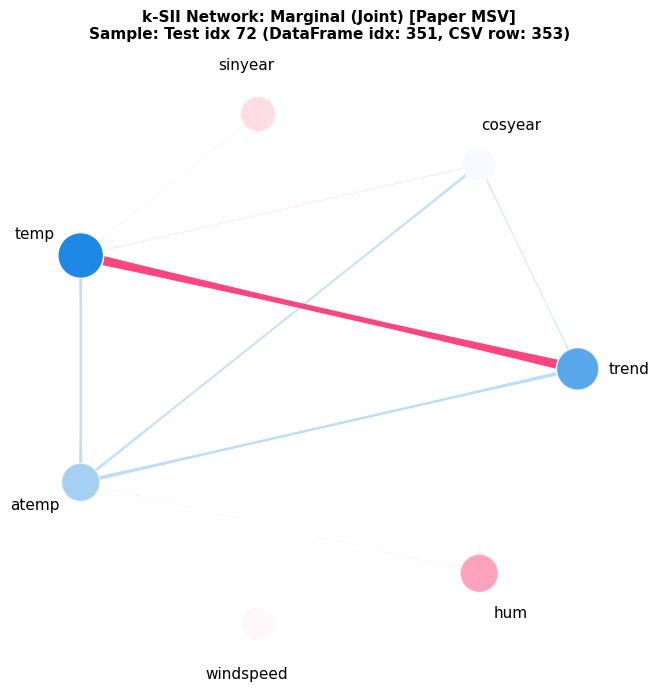


k-SII Network: Marginal (Gaussian)


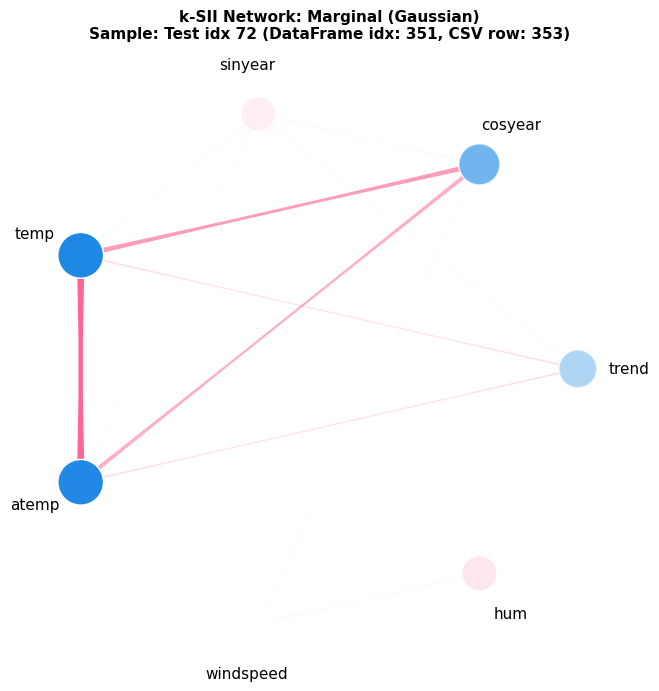


k-SII Network: Marginal (Copula)


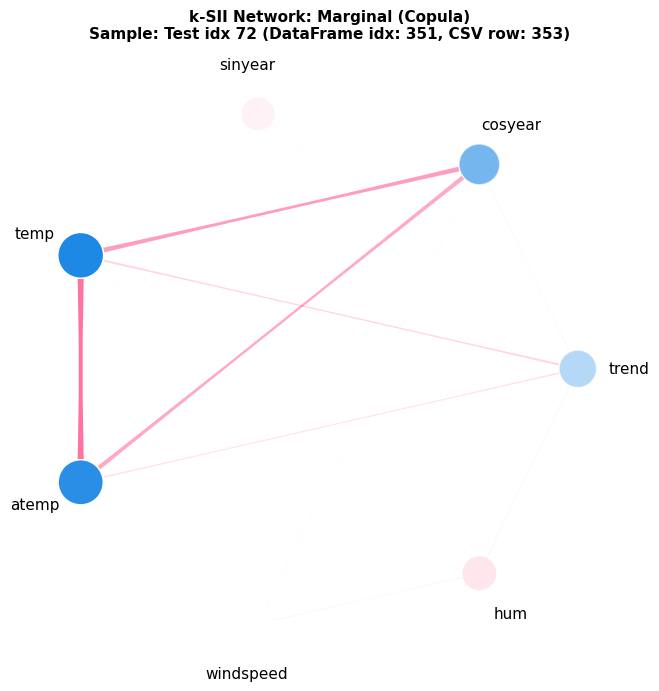


k-SII Network: Causal+Model (Gaussian) ★[Paper CSV]


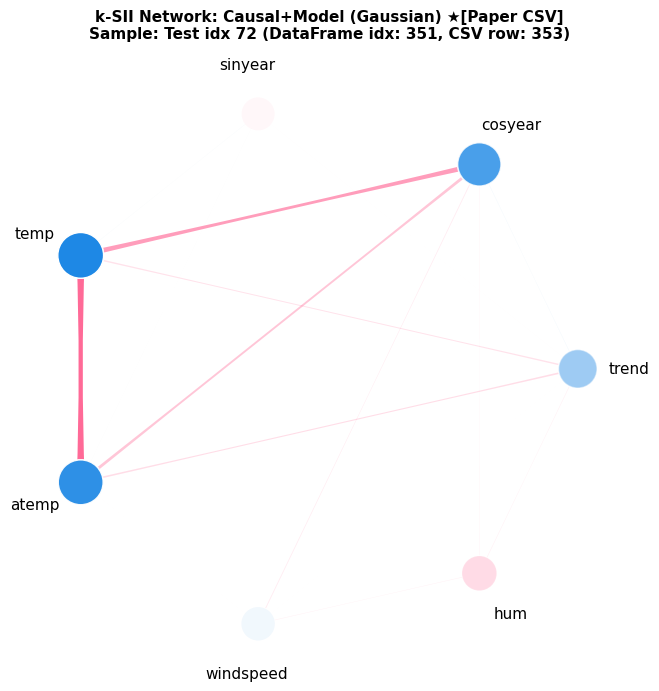


k-SII Network: Causal+Model (Copula)


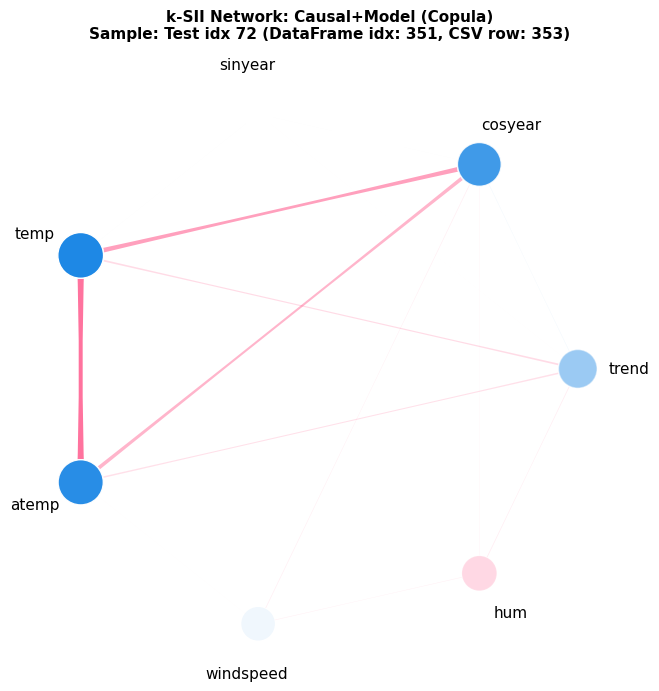


k-SII Network: Causal No-Model (Copula)


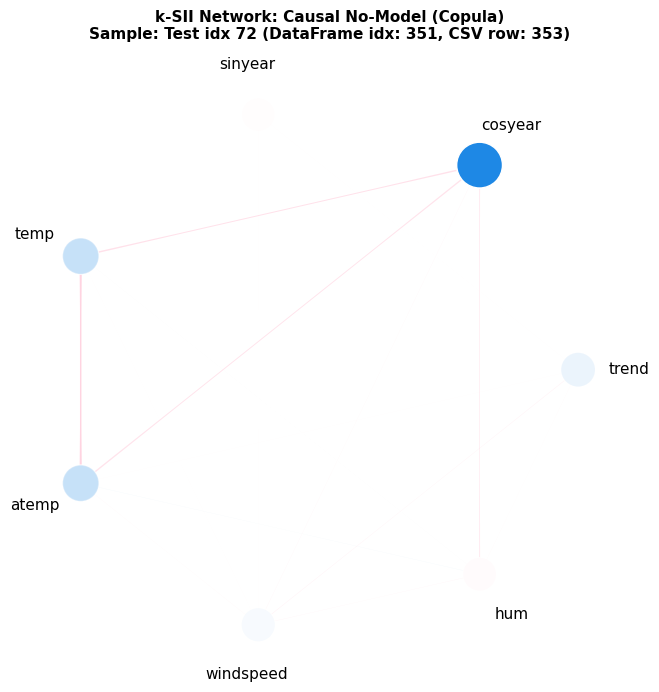


Sample: Test index 72 (DataFrame idx: 351, CSV row: 353)
Note: Using pre-computed k-SII values from Section 5
Node size = main effect, Edge width = interaction strength


In [ ]:
# Plot k-SII Network Graphs for all 6 methods
# Note: plot_network() creates its own figure, so we plot them individually

# Get test CSV row for display
test_csv_row = test_idx[sample_idx] + 2  # CSV row = DataFrame index + 2

print("k-SII Network Graphs for all 6 methods:")
print("=" * 60)
print(f"Sample: Test index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")

for exp_name, result in ksii_results.items():
    # Mark paper methods in title
    title = f"k-SII Network: {exp_name}"
    if exp_name == 'Marginal (Gaussian)':
        title += ' ★[Paper MSV]'
    elif exp_name == 'Causal+Model (Gaussian)':
        title += ' ★[Paper CSV]'
    
    print(f"\n{title}")
    
    # plot_network creates its own figure
    fig, ax = result.plot_network(feature_names=feature_names, show=False)
    fig.suptitle(f"{title}\nSample: Test idx {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})", 
                fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print(f"Sample: Test index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")
print("Note: Using pre-computed k-SII values from Section 5")
print("Node size = main effect, Edge width = interaction strength")

In [ ]:
# Print interaction values summary for key feature pairs
test_csv_row = test_idx[sample_idx] + 2
print("="*90)
print("k-SII INTERACTION VALUES COMPARISON")
print(f"Sample: Test index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")
print("="*90)

# Key feature pairs to compare
key_pairs = [
    (feature_names.index('temp'), feature_names.index('cosyear')),
    (feature_names.index('temp'), feature_names.index('atemp')),
    (feature_names.index('cosyear'), feature_names.index('sinyear')),
    (feature_names.index('temp'), feature_names.index('hum')),
    (feature_names.index('trend'), feature_names.index('cosyear')),
]

print("\n" + "-"*90)
print(f"{'Feature Pair':<25} ", end="")
for exp_name in ksii_results.keys():
    short_name = exp_name.split('(')[0].strip()[:8]
    print(f"{short_name:>10}", end="")
print()
print("-"*90)

for i, j in key_pairs:
    pair_name = f"({feature_names[i]}, {feature_names[j]})"
    print(f"{pair_name:<25} ", end="")
    for exp_name, result in ksii_results.items():
        # Get interaction value for this pair using try/except
        try:
            interaction_val = result[(i, j)]
        except (KeyError, IndexError):
            try:
                interaction_val = result[(j, i)]
            except (KeyError, IndexError):
                interaction_val = 0.0
        print(f"{interaction_val:>10.3f}", end="")
    print()

print("\n" + "-"*90)
print("1st-order (Main Effects):")
print("-"*90)
print(f"{'Feature':<25} ", end="")
for exp_name in ksii_results.keys():
    short_name = exp_name.split('(')[0].strip()[:8]
    print(f"{short_name:>10}", end="")
print()
print("-"*90)

for i, fname in enumerate(feature_names):
    print(f"{fname:<25} ", end="")
    for exp_name, result in ksii_results.items():
        try:
            main_effect = result[(i,)]
        except (KeyError, IndexError):
            main_effect = 0.0
        print(f"{main_effect:>10.3f}", end="")
    print()

print("\n" + "="*90)
print("INTERPRETATION:")
print("="*90)
print("""
Key observations from k-SII network graphs:

1. NODE SIZE (Main Effects):
   - Marginal methods: temp has large node (high main effect)
   - Causal methods: cosyear absorbs attribution from temp

2. EDGE THICKNESS (Interactions):
   - Marginal: Strong temp-cosyear interaction (spurious correlation)
   - Causal: Reduced temp-cosyear interaction (causal structure removes spurious correlation)

3. NETWORK STRUCTURE:
   - Marginal: Dense connections (correlations treated as interactions)
   - Causal: Sparser connections (only genuine causal interactions remain)

4. CAUSAL INSIGHT:
   - The causal structure removes the apparent temp-cosyear "interaction"
   - This is because season (cosyear) CAUSES temperature, not interacts with it
   - True interactions are preserved (e.g., temp-atemp, temp-hum)
""")

k-SII INTERACTION VALUES COMPARISON
Sample: Test index 72 (DataFrame idx: 351, CSV row: 353)

------------------------------------------------------------------------------------------
Feature Pair                Marginal  Marginal  Marginal  Causal+M  Causal+M  Causal N
------------------------------------------------------------------------------------------
(temp, cosyear)               97.174   679.427   659.266   527.147   493.149   192.194
(temp, atemp)               -262.439  1056.611   943.249   801.769   722.099   280.058
(cosyear, sinyear)           -41.226   105.933    27.679    -0.550   -17.741     2.837
(temp, hum)                  -34.521    54.770    59.568    -4.861     3.705   -25.658
(trend, cosyear)            -157.187    13.493   -88.947   -61.536   -63.549   -17.054

------------------------------------------------------------------------------------------
1st-order (Main Effects):
------------------------------------------------------------------------------------

In [ ]:
# Aggregated k-SII comparison across multiple test samples
# Using pre-computed k-SII results from Section 5 + shapiq's aggregate_interaction_values
from shapiq.interaction_values import aggregate_interaction_values

print("Aggregating pre-computed k-SII results across multiple test samples...")

n_samples_ksii = 10  # Use subset for visualization
sample_indices = np.linspace(0, len(X_test)-1, n_samples_ksii, dtype=int)

# Get CSV row info for display
agg_test_csv_rows = test_idx[sample_indices] + 2
print(f"Using {n_samples_ksii} samples: DataFrame idx {test_idx[sample_indices].tolist()}")
print(f"                   CSV rows {agg_test_csv_rows.tolist()}")

# Retrieve pre-computed k-SII results and aggregate
agg_ksii_results = {}

for exp_name in all_ksii.keys():
    # Get pre-computed results for selected sample indices
    results_list = [all_ksii[exp_name][i] for i in sample_indices]
    agg_ksii_results[exp_name] = aggregate_interaction_values(results_list)
    print(f"  {exp_name}: Aggregated from {len(results_list)} pre-computed samples")

print("\nDone!")
print(f"Aggregated k-SII values ready for {len(agg_ksii_results)} methods.")

Aggregating pre-computed k-SII results across multiple test samples...
Using 10 samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
                   CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]
  Marginal (Joint): Aggregated from 10 pre-computed samples
  Marginal (Gaussian): Aggregated from 10 pre-computed samples
  Marginal (Copula): Aggregated from 10 pre-computed samples
  Causal+Model (Gaussian): Aggregated from 10 pre-computed samples
  Causal+Model (Copula): Aggregated from 10 pre-computed samples
  Causal No-Model (Copula): Aggregated from 10 pre-computed samples

Done!
Aggregated k-SII values ready for 6 methods.


Aggregated k-SII Network Graphs (Average over 10 test samples):
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
         CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]

Aggregated k-SII Network: Marginal (Joint) [Paper MSV]


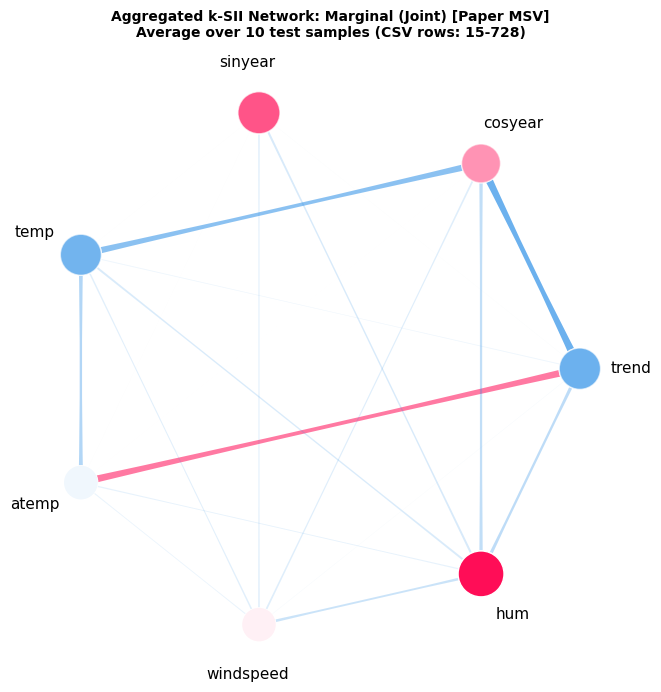


Aggregated k-SII Network: Marginal (Gaussian)


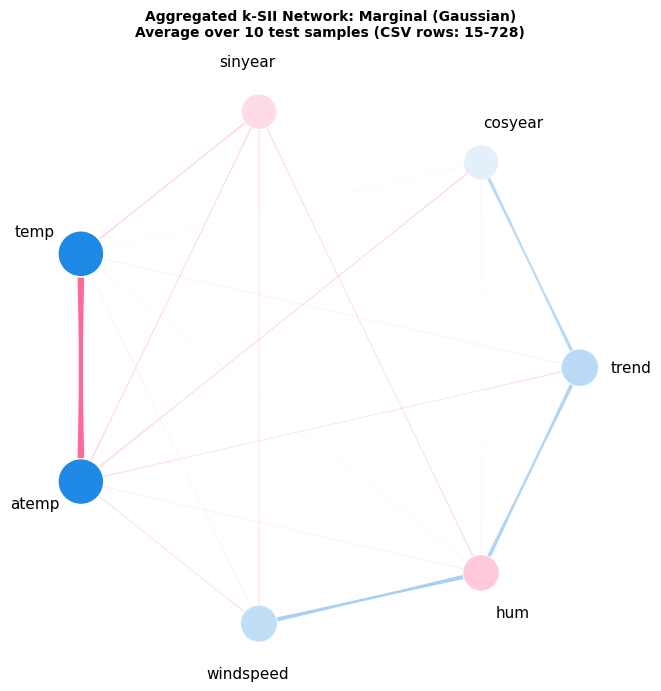


Aggregated k-SII Network: Marginal (Copula)


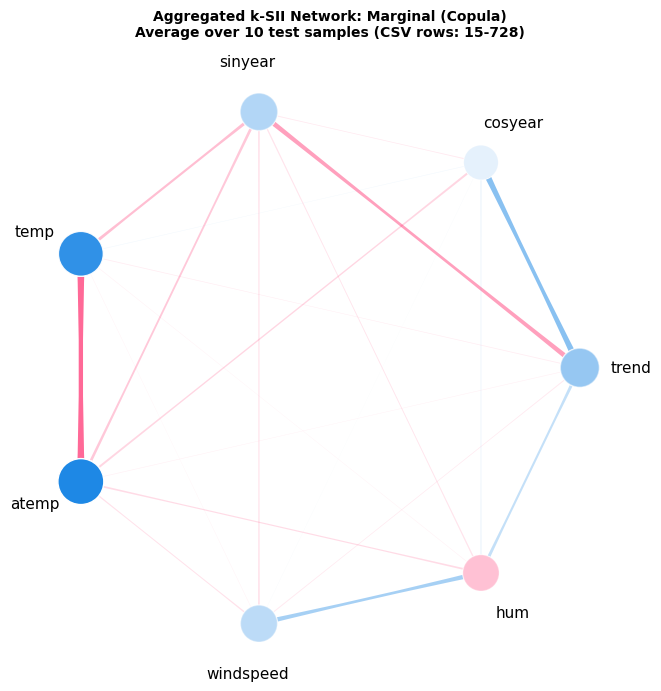


Aggregated k-SII Network: Causal+Model (Gaussian) ★[Paper CSV]


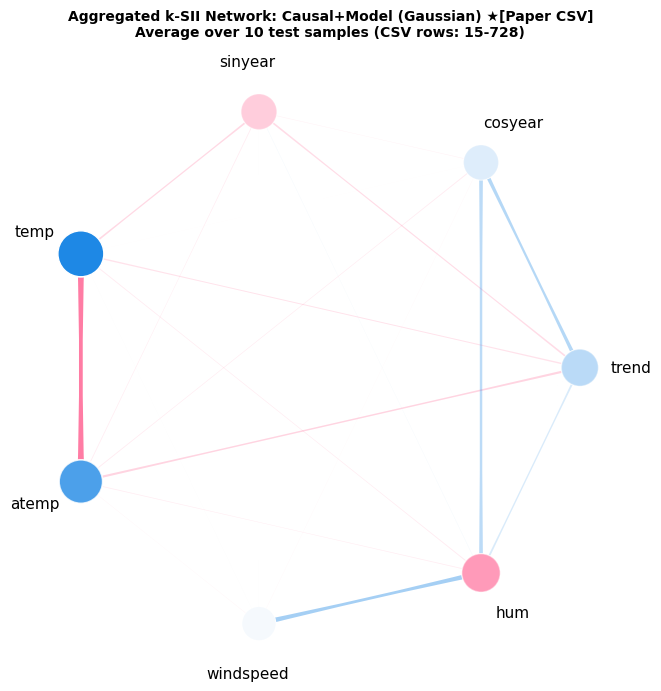


Aggregated k-SII Network: Causal+Model (Copula)


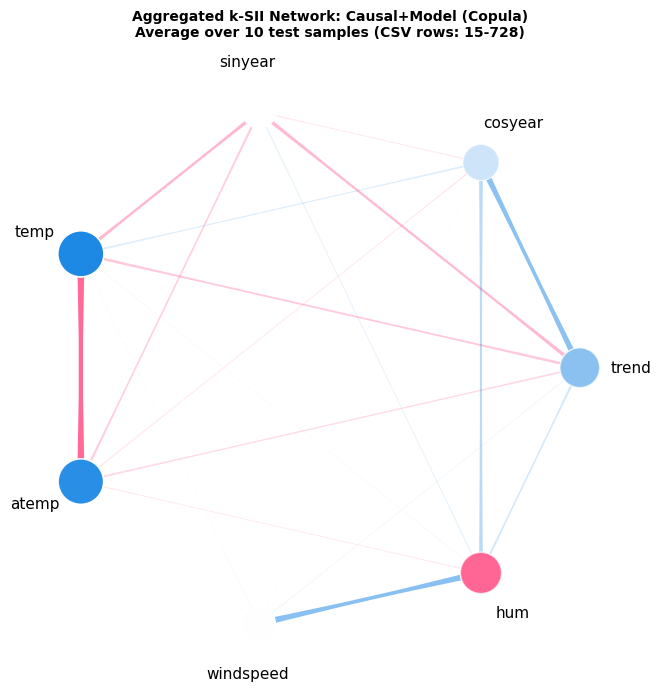


Aggregated k-SII Network: Causal No-Model (Copula)


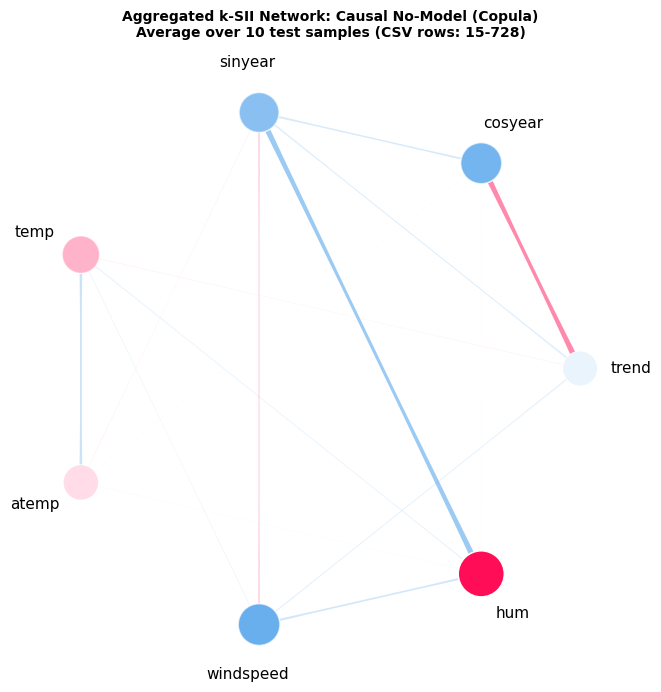


Aggregated k-SII network plots over 10 samples
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
         CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]
Note: These show the AVERAGE interaction patterns across multiple samples


In [ ]:
# Plot aggregated k-SII network graphs
print(f"Aggregated k-SII Network Graphs (Average over {n_samples_ksii} test samples):")
print("=" * 70)
print(f"Samples: DataFrame idx {test_idx[sample_indices].tolist()}")
print(f"         CSV rows {(test_idx[sample_indices] + 2).tolist()}")

for exp_name, agg_result in agg_ksii_results.items():
    title = f"Aggregated k-SII Network: {exp_name}"
    if exp_name == 'Marginal (Gaussian)':
        title += ' ★[Paper MSV]'
    elif exp_name == 'Causal+Model (Gaussian)':
        title += ' ★[Paper CSV]'
    
    print(f"\n{title}")
    
    fig, ax = agg_result.plot_network(feature_names=feature_names, show=False)
    fig.suptitle(f"{title}\nAverage over {n_samples_ksii} test samples (CSV rows: {(test_idx[sample_indices] + 2)[0]}-{(test_idx[sample_indices] + 2)[-1]})", 
                fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\nAggregated k-SII network plots over {n_samples_ksii} samples")
print(f"Samples: DataFrame idx {test_idx[sample_indices].tolist()}")
print(f"         CSV rows {(test_idx[sample_indices] + 2).tolist()}")
print("Note: These show the AVERAGE interaction patterns across multiple samples")

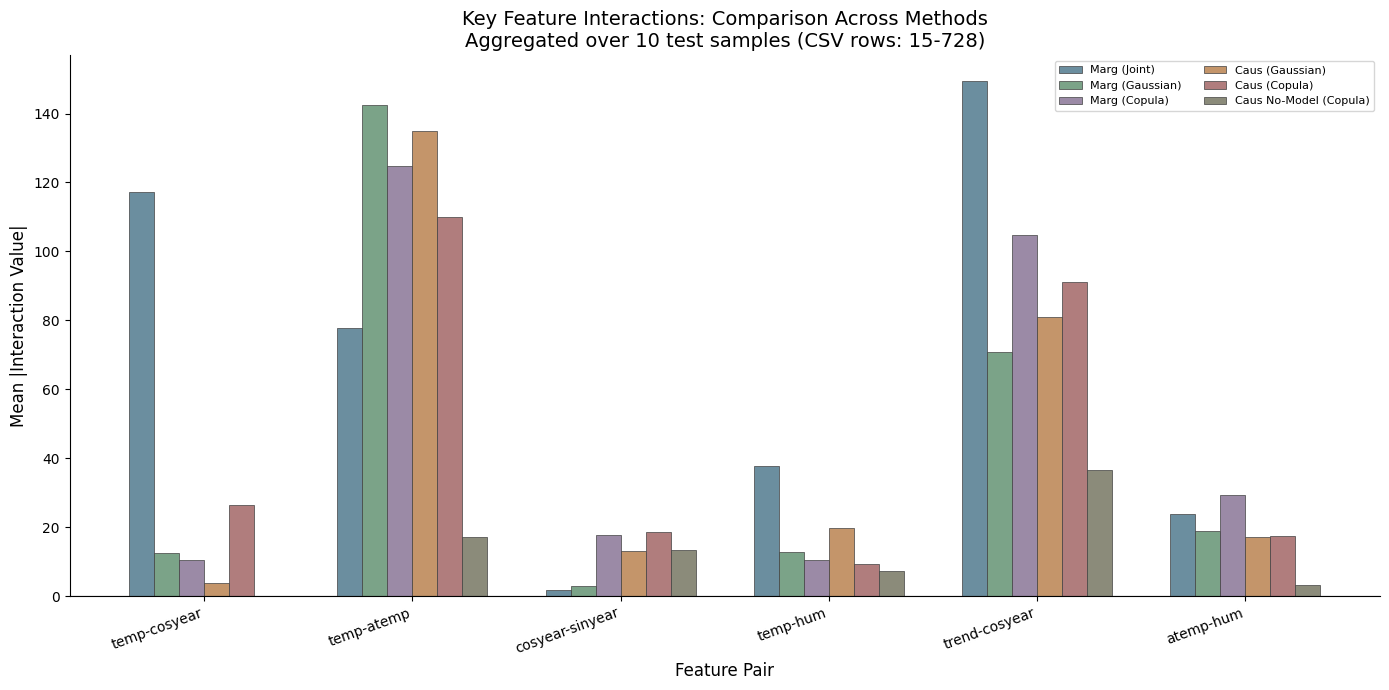


KEY FINDING: temp-cosyear Interaction
  Marginal (Joint)              : 117.1082
  Marginal (Gaussian)           : 12.3959
  Marginal (Copula)             : 10.5885
  Causal+Model (Gaussian)       : 3.8555 ★
  Causal+Model (Copula)         : 26.4350
  Causal No-Model (Copula)      : 0.0599

The temp-cosyear interaction pattern differs between methods:
- Marginal methods treat correlation as interaction
- Causal methods model the dependency structure explicitly
- With the causal ordering (trend→season→weather),
  the interaction pattern reflects the true dependency structure.



In [ ]:
# Bar chart: Key interaction pairs comparison using aggregated k-SII results
fig, ax = plt.subplots(figsize=(14, 7))

key_pairs_names = [
    ('temp', 'cosyear'),
    ('temp', 'atemp'),
    ('cosyear', 'sinyear'),
    ('temp', 'hum'),
    ('trend', 'cosyear'),
    ('atemp', 'hum'),
]

x = np.arange(len(key_pairs_names))
width = 0.12
multiplier = 0

# Academic color palette
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#7BA388',  # Muted sage green (Marginal Gaussian)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#C4956A',  # Muted terracotta (Causal Gaussian) ★
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-Model)
]

for color_idx, (exp_name, agg_result) in enumerate(agg_ksii_results.items()):
    values = []
    for f1, f2 in key_pairs_names:
        i, j = feature_names.index(f1), feature_names.index(f2)
        # Get interaction value from aggregated result using try/except
        try:
            interaction_val = abs(agg_result[(i, j)])
        except (KeyError, IndexError):
            try:
                interaction_val = abs(agg_result[(j, i)])
            except (KeyError, IndexError):
                interaction_val = 0.0
        values.append(interaction_val)
    
    offset = width * multiplier
    short_name = exp_name.replace('Marginal', 'Marg').replace('Causal', 'Caus').replace('+Model', '')
    bars = ax.bar(x + offset, values, width, label=short_name, 
                 color=colors[color_idx], edgecolor='#404040', linewidth=0.5)
    multiplier += 1

ax.set_ylabel('Mean |Interaction Value|', fontsize=12)
ax.set_xlabel('Feature Pair', fontsize=12)
ax.set_title(f'Key Feature Interactions: Comparison Across Methods\n'
            f'Aggregated over {n_samples_ksii} test samples (CSV rows: {(test_idx[sample_indices] + 2)[0]}-{(test_idx[sample_indices] + 2)[-1]})', 
            fontsize=14)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels([f'{f1}-{f2}' for f1, f2 in key_pairs_names], fontsize=10, rotation=20, ha='right')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("KEY FINDING: temp-cosyear Interaction")
print("="*80)
temp_i, cosyear_i = feature_names.index('temp'), feature_names.index('cosyear')
for exp_name, agg_result in agg_ksii_results.items():
    try:
        val = abs(agg_result[(temp_i, cosyear_i)])
    except (KeyError, IndexError):
        try:
            val = abs(agg_result[(cosyear_i, temp_i)])
        except (KeyError, IndexError):
            val = 0.0
    marker = " ★" if exp_name == 'Causal+Model (Gaussian)' else ""
    print(f"  {exp_name:<30}: {val:.4f}{marker}")

print("""
The temp-cosyear interaction pattern differs between methods:
- Marginal methods treat correlation as interaction
- Causal methods model the dependency structure explicitly
- With the causal ordering (trend→season→weather),
  the interaction pattern reflects the true dependency structure.
""")